<div style="border: 5px solid black; padding: 10px;">

# **DSC530 – Data Exploration and Analysis**

## **Timothy Hollis**  
## **Term Project: Linguistic Patterns and Lyrical Characteristics in Rap Music**  
## **March 2, 2026**

---

## **Problem Statement**

Rap music is widely recognized for its linguistic creativity, emotional depth, and cultural impact. While discussions about the complexity, sentiment, and thematic content of rap lyrics are common, these claims are rarely evaluated using large-scale empirical data. This project uses a corpus of 100,000 rap lyrics to conduct a comprehensive exploratory data analysis (EDA) focused on understanding the linguistic and stylistic characteristics of the genre.

The primary goal is to quantify patterns in vocabulary richness, sentiment, thematic structure, and stylistic tendencies within rap lyrics. By applying statistical methods, visualization techniques, and machine learning models, this project seeks to uncover meaningful insights about how rap lyrics are constructed and what linguistic features define the genre. The analysis includes descriptive statistics, univariate and bivariate exploration, hypothesis testing, regression, classification, clustering, and advanced NLP-based feature engineering to provide a data-driven perspective on rap lyricism.

---

## **Project Objectives**

This project will address the following analytical questions:

1. **What does vocabulary richness look like across a large corpus of rap lyrics, and how does it vary across songs?**  
2. **What sentiment patterns appear in rap lyrics, and what linguistic features are associated with more positive or negative sentiment?**  
3. **What dominant lyrical topics emerge from the corpus, and how do these themes characterize rap lyricism?**  
4. **Can a machine learning model classify a song's genre based solely on its lyrics?**  
5. **Do clusters of rap songs reveal distinct thematic or stylistic groupings within the genre?**

---

# Dataset Source & Loading

The dataset used for this project is the *English Lyrics Dataset from Five Music Genres*, downloaded from Kaggle and extracted locally. The primary file used in this analysis is `cleaned_train_lyrics.csv`, which contains over 500,000 English-language song lyrics labeled across five genres: Rap, Pop, Rock, Metal, and Country.

**Dataset Link:** [English Lyrics Dataset — Kaggle](https://www.kaggle.com/datasets/d3stron/english-music-lyrics-5-genres-500k)

Each record includes a genre label and the full cleaned lyrics for a single song. This dataset provides a large, diverse, and genre-balanced corpus suitable for exploratory analysis, sentiment evaluation, vocabulary richness calculations, topic modeling, and machine learning tasks.

For analyses focused specifically on rap lyricism, a subset of 100,000 rap songs is created from the full dataset. However, the complete five-genre dataset is retained for tasks such as genre classification and clustering, where multiple categories are required.

---

## **Approach**

The analysis will include:

- **Data Cleaning & Preparation:**  
  Handling missing values, performing text preprocessing (lowercasing, punctuation removal, stopword removal, tokenization, lemmatization), engineering numerical features such as word count, character count, sentiment score, and vocabulary richness, and encoding categorical variables when needed.

- **Univariate & Bivariate Analysis:**  
  Summary statistics and distribution visualizations for key engineered variables (e.g., lyric length, sentiment, vocabulary richness).  
  Correlation analysis and pairwise comparisons between numeric features to understand relationships within the rap corpus and across genres when applicable.

- **Hypothesis Testing:**  
  Statistical tests evaluating claims such as whether vocabulary richness differs significantly between rap and other genres, or whether sentiment varies across songs.  
  Assumptions will be checked and results interpreted using appropriate test statistics.

- **Regression & Classification Models:**  
  Regression models predicting numeric outcomes such as sentiment or vocabulary richness.  
  Classification models predicting song genre based solely on lyrics using TF-IDF or other NLP-derived features.

- **Clustering & Topic Modeling:**  
  Grouping songs by lyrical themes using TF-IDF, PCA, and K-Means.  
  Identifying dominant topics within rap lyrics using topic modeling techniques such as LDA or NMF.

- **Data Storytelling:**  
  A narrative synthesizing insights about linguistic patterns, sentiment tendencies, thematic structure, and stylistic characteristics within rap lyrics, supported by impactful visualizations and actionable conclusions.

---

## **Expected Outcomes**

By the end of this project, the analysis will provide:

- Quantitative measures of vocabulary richness, sentiment, and stylistic characteristics within rap lyrics  
- Visualizations that highlight key linguistic patterns and distributions across the corpus  
- Machine learning models that demonstrate the feasibility of predicting song genre or sentiment from lyrics alone  
- Clusters and topics that reveal underlying thematic structure within rap music  
- Actionable insights into the linguistic features that define rap lyricism and distinguish it from other genres

### **Initial Setup**

The following code cell loads the required libraries, configures display and visualization settings, imports the full lyrics dataset into a pandas DataFrame, and previews the first few rows to confirm structure and variable availability.

In [23]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import re
import string
import nltk
from collections import Counter

from nltk.util import ngrams
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score,
    silhouette_score
)
from scipy import stats

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.width', 1000)

# Visualization Settings
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Colorblind-Safe Palette
COLORS = {
    'blue': '#2166AC',
    'purple': '#762A83',
    'green': '#1B7837',
    'orange': '#E08214',
    'red': '#D6604D',
    'grey': '#878787',
}

GENRE_COLORS = {
    'rap': '#2166AC',
    'rock': '#762A83',
    'pop': '#1B7837',
    'country': '#E08214',
    'Metal': '#D6604D',
}

# Load Full Dataset
lyrics_df = pd.read_csv('cleaned_train_lyrics.csv')

# Normalize genre casing
lyrics_df['genre'] = lyrics_df['genre'].str.lower()

# Drop unnecessary index column
lyrics_df = lyrics_df.drop(columns=['Unnamed: 0'])

# Create Rap Subset
rap_df = lyrics_df[lyrics_df['genre'] == 'rap'].copy().reset_index(drop=True)

# Text Preprocessing
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
analyzer = SentimentIntensityAnalyzer()


def preprocess(text):
    """Preprocess a raw lyric string for NLP analysis."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)


# Engineer Features on Rap Subset
rap_df['char_count'] = rap_df['Lyric'].str.len()
rap_df['word_count'] = rap_df['Lyric'].str.split().apply(len)
rap_df['unique_word_count'] = rap_df['Lyric'].str.split().apply(
    lambda x: len(set(x)))
rap_df['ttr'] = rap_df['unique_word_count'] / rap_df['word_count']
rap_df['sentiment_score'] = rap_df['Lyric'].apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)

# Preview/Confirmation
print('✅ All libraries loaded successfully!')
print(
    f'📦 Full dataset     : {lyrics_df.shape[0]:,} rows x {lyrics_df.shape[1]} columns')
print(
    f'🎤 Rap subset       : {rap_df.shape[0]:,} rows x {rap_df.shape[1]} columns')
print(f'🎨 Genres confirmed : {sorted(lyrics_df["genre"].unique())}')
print(f'\n📊 Rap Feature Preview:')
display(rap_df[['Lyric', 'char_count', 'word_count',
        'ttr', 'sentiment_score']].head(3))

✅ All libraries loaded successfully!
📦 Full dataset     : 500,000 rows x 2 columns
🎤 Rap subset       : 100,000 rows x 7 columns
🎨 Genres confirmed : ['country', 'metal', 'pop', 'rap', 'rock']

📊 Rap Feature Preview:


,Lyric,char_count,word_count,ttr,sentiment_score
0,Suge White Shot me [Korean Intro] [Verse 1] De...,1998,400,0.5725,0.9913
1,Shout out to everybody listening to the Slings...,306,55,0.8364,0.3182
2,Oh My God Its bout to go down Diss ya boy Mr. ...,829,178,0.6629,0.8209


---

## Section 1: Variable Characteristics and Summary Statistics

Before conducting any statistical analysis, it is important to understand the structure 
and distribution of the variables in this dataset. This section describes each engineered 
feature, provides summary statistics, and examines the overall shape of the data to 
identify any immediate concerns such as skewness, outliers, or unexpected distributions.

**Engineered Features (Rap Subset):**
| Feature | Type | Description |
|---|---|---|
| `char_count` | Numeric | Total number of characters in the raw lyric |
| `word_count` | Numeric | Total number of words in the raw lyric |
| `unique_word_count` | Numeric | Number of distinct words in the raw lyric |
| `ttr` | Numeric | Type-Token Ratio — unique words divided by total words (vocabulary richness) |
| `sentiment_score` | Numeric | VADER compound sentiment score ranging from -1 (negative) to +1 (positive) |

**Genre Variable (Full Dataset):**
| Feature | Type | Description |
|---|---|---|
| `genre` | Categorical | Music genre label — one of: rap, rock, pop, country, metal |
| `Lyric` | Text | Full raw lyric string for each song |

### Steps to Complete
1. Calculate summary statistics (count, mean, std, min, max, quartiles) for all engineered numeric features.
2. Calculate extended statistics including median, mode, variance, skewness, and kurtosis.
3. Examine the genre distribution across the full dataset.
4. Break down sentiment scores into negative, neutral, and positive categories.

---

In [24]:
# 1. Calculate summary statistics for all engineered numeric features
print('📊 Summary Statistics — Rap Subset Engineered Features:')
summary_stats = rap_df[['char_count', 'word_count',
                        'unique_word_count', 'ttr', 'sentiment_score']].describe()
display(summary_stats)

# 2. Calculate extended statistics including median, mode, variance,
# skewness, and kurtosis.
print('\n📊 Extended Statistics:')
extended_stats = pd.DataFrame({
    'mean': rap_df[['char_count', 'word_count', 'unique_word_count', 'ttr', 'sentiment_score']].mean(),
    'median': rap_df[['char_count', 'word_count', 'unique_word_count', 'ttr', 'sentiment_score']].median(),
    'mode': rap_df[['char_count', 'word_count', 'unique_word_count', 'ttr', 'sentiment_score']].mode().iloc[0],
    'variance': rap_df[['char_count', 'word_count', 'unique_word_count', 'ttr', 'sentiment_score']].var(),
    'skewness': rap_df[['char_count', 'word_count', 'unique_word_count', 'ttr', 'sentiment_score']].skew(),
    'kurtosis': rap_df[['char_count', 'word_count', 'unique_word_count', 'ttr', 'sentiment_score']].kurt()
})
display(extended_stats)

# 3. Examine the genre distribution across the full dataset.
print('\n📊 Genre Distribution — Full Dataset:')
genre_counts = lyrics_df['genre'].value_counts().reset_index()
genre_counts.columns = ['genre', 'count']
display(genre_counts)

# 4. Break down sentiment scores into negative, neutral, and positive
# categories
print('\n📊 Sentiment Score Breakdown:')
sentiment_bins = pd.cut(
    rap_df['sentiment_score'],
    bins=[-1, -0.05, 0.05, 1],
    labels=['Negative', 'Neutral', 'Positive']
)
sentiment_summary = sentiment_bins.value_counts().reset_index()
sentiment_summary.columns = ['sentiment', 'count']
sentiment_summary['pct'] = (
    sentiment_summary['count'] /
    len(rap_df) *
    100).round(1)
display(sentiment_summary)

print(f'\n✅ Summary statistics complete')
print(f'   Total rap songs analyzed : {len(rap_df):,}')
print(f'   Total genres in dataset  : {lyrics_df["genre"].nunique():,}')

📊 Summary Statistics — Rap Subset Engineered Features:


,char_count,word_count,unique_word_count,ttr,sentiment_score
count,"100,000.0000","100,000.0000","100,000.0000","100,000.0000","100,000.0000"
mean,"2,172.9990",430.7014,223.9126,0.5560,0.1074
std,"1,453.6559",272.6787,107.1130,0.1253,0.8971
min,69.0000,1.0000,1.0000,0.0365,-1.0000
25%,"1,425.0000",283.0000,157.0000,0.4734,-0.9571
50%,"2,084.0000",415.0000,220.0000,0.5574,0.6310
75%,"2,769.0000",551.0000,282.0000,0.6352,0.9809
max,"91,091.0000","16,511.0000","4,014.0000",1.0000,1.0000



📊 Extended Statistics:


,mean,median,mode,variance,skewness,kurtosis
char_count,"2,172.9990","2,084.0000","1,774.0000","2,113,115.4242",17.9415,794.7444
word_count,430.7014,415.0000,405.0000,"74,353.6982",15.1828,643.4278
unique_word_count,223.9126,220.0000,211.0000,"11,473.1857",4.1216,88.4191
ttr,0.5560,0.5574,0.6667,0.0157,0.0863,0.3125
sentiment_score,0.1074,0.6310,0.9992,0.8047,-0.2232,-1.8422



📊 Genre Distribution — Full Dataset:


,genre,count
0,metal,100000
1,rock,100000
2,rap,100000
3,pop,100000
4,country,100000



📊 Sentiment Score Breakdown:


,sentiment,count,pct
0,Positive,55393,55.4000
1,Negative,43993,44.0000
2,Neutral,608,0.6000



✅ Summary statistics complete
   Total rap songs analyzed : 100,000
   Total genres in dataset  : 5


<div style="border: 2px solid black; padding: 10px;">

## Summary of Section 1: Variable Characteristics and Summary Statistics

The rap lyric corpus consists of **100,000 songs** with five engineered numeric 
features and one categorical variable. All features were computed directly from 
the raw lyric text with zero missing values across the dataset.

**Character Count** averaged **2,173 characters** per song with high variability 
(std: 1,454), indicating significant differences in lyric length across the corpus. 
The maximum of **91,091 characters** suggests the presence of extreme outliers 
likely representing data quality issues.

**Word Count** averaged **431 words** per song with a skewness of **15.18** — 
one of the most right-skewed features in the dataset. The high kurtosis of **643** 
confirms a heavy-tailed distribution driven by a small number of extremely long lyrics.

**Type-Token Ratio (TTR)** had a mean of **0.556** and was the most normally 
distributed feature with skewness of only **0.086**. This measure of vocabulary 
richness will serve as a key variable in regression and hypothesis testing.

**Sentiment Score** averaged **0.107** (mildly positive) but had a median of 
**0.631**, revealing that the mean is pulled down by a subset of highly negative 
songs. With **55.4% positive**, **44% negative**, and only **0.6% neutral**, 
rap lyrics are rarely emotionally ambiguous.

**Genre Distribution** across the full 500,000-song dataset was perfectly balanced 
at **100,000 songs per genre**, making it ideal for multi-class classification 
without requiring any resampling techniques.

<span style='color: green;'>**The summary statistics confirm a rich, variable, 
and emotionally expressive corpus well-suited for NLP analysis, machine learning, 
and statistical inference.**</span>

## Section 2: Univariate Analysis

Univariate analysis examines each variable individually to understand its distribution, 
central tendency, spread, and shape. This section visualizes the key engineered features 
using histograms, box plots, and density plots to identify patterns, skewness, and 
outliers within the rap lyric corpus.

### Steps to Complete
1. Visualize the distribution of `char_count` using a histogram and density plot.
2. Visualize the distribution of `word_count` using a histogram and box plot.
3. Visualize the distribution of `ttr` (vocabulary richness) using a histogram and density plot.
4. Visualize the distribution of `sentiment_score` using a histogram and density plot.
5. Visualize the genre distribution across the full dataset using a bar chart.
6. Identify and discuss outliers in `word_count` and `char_count` using box plots.

---

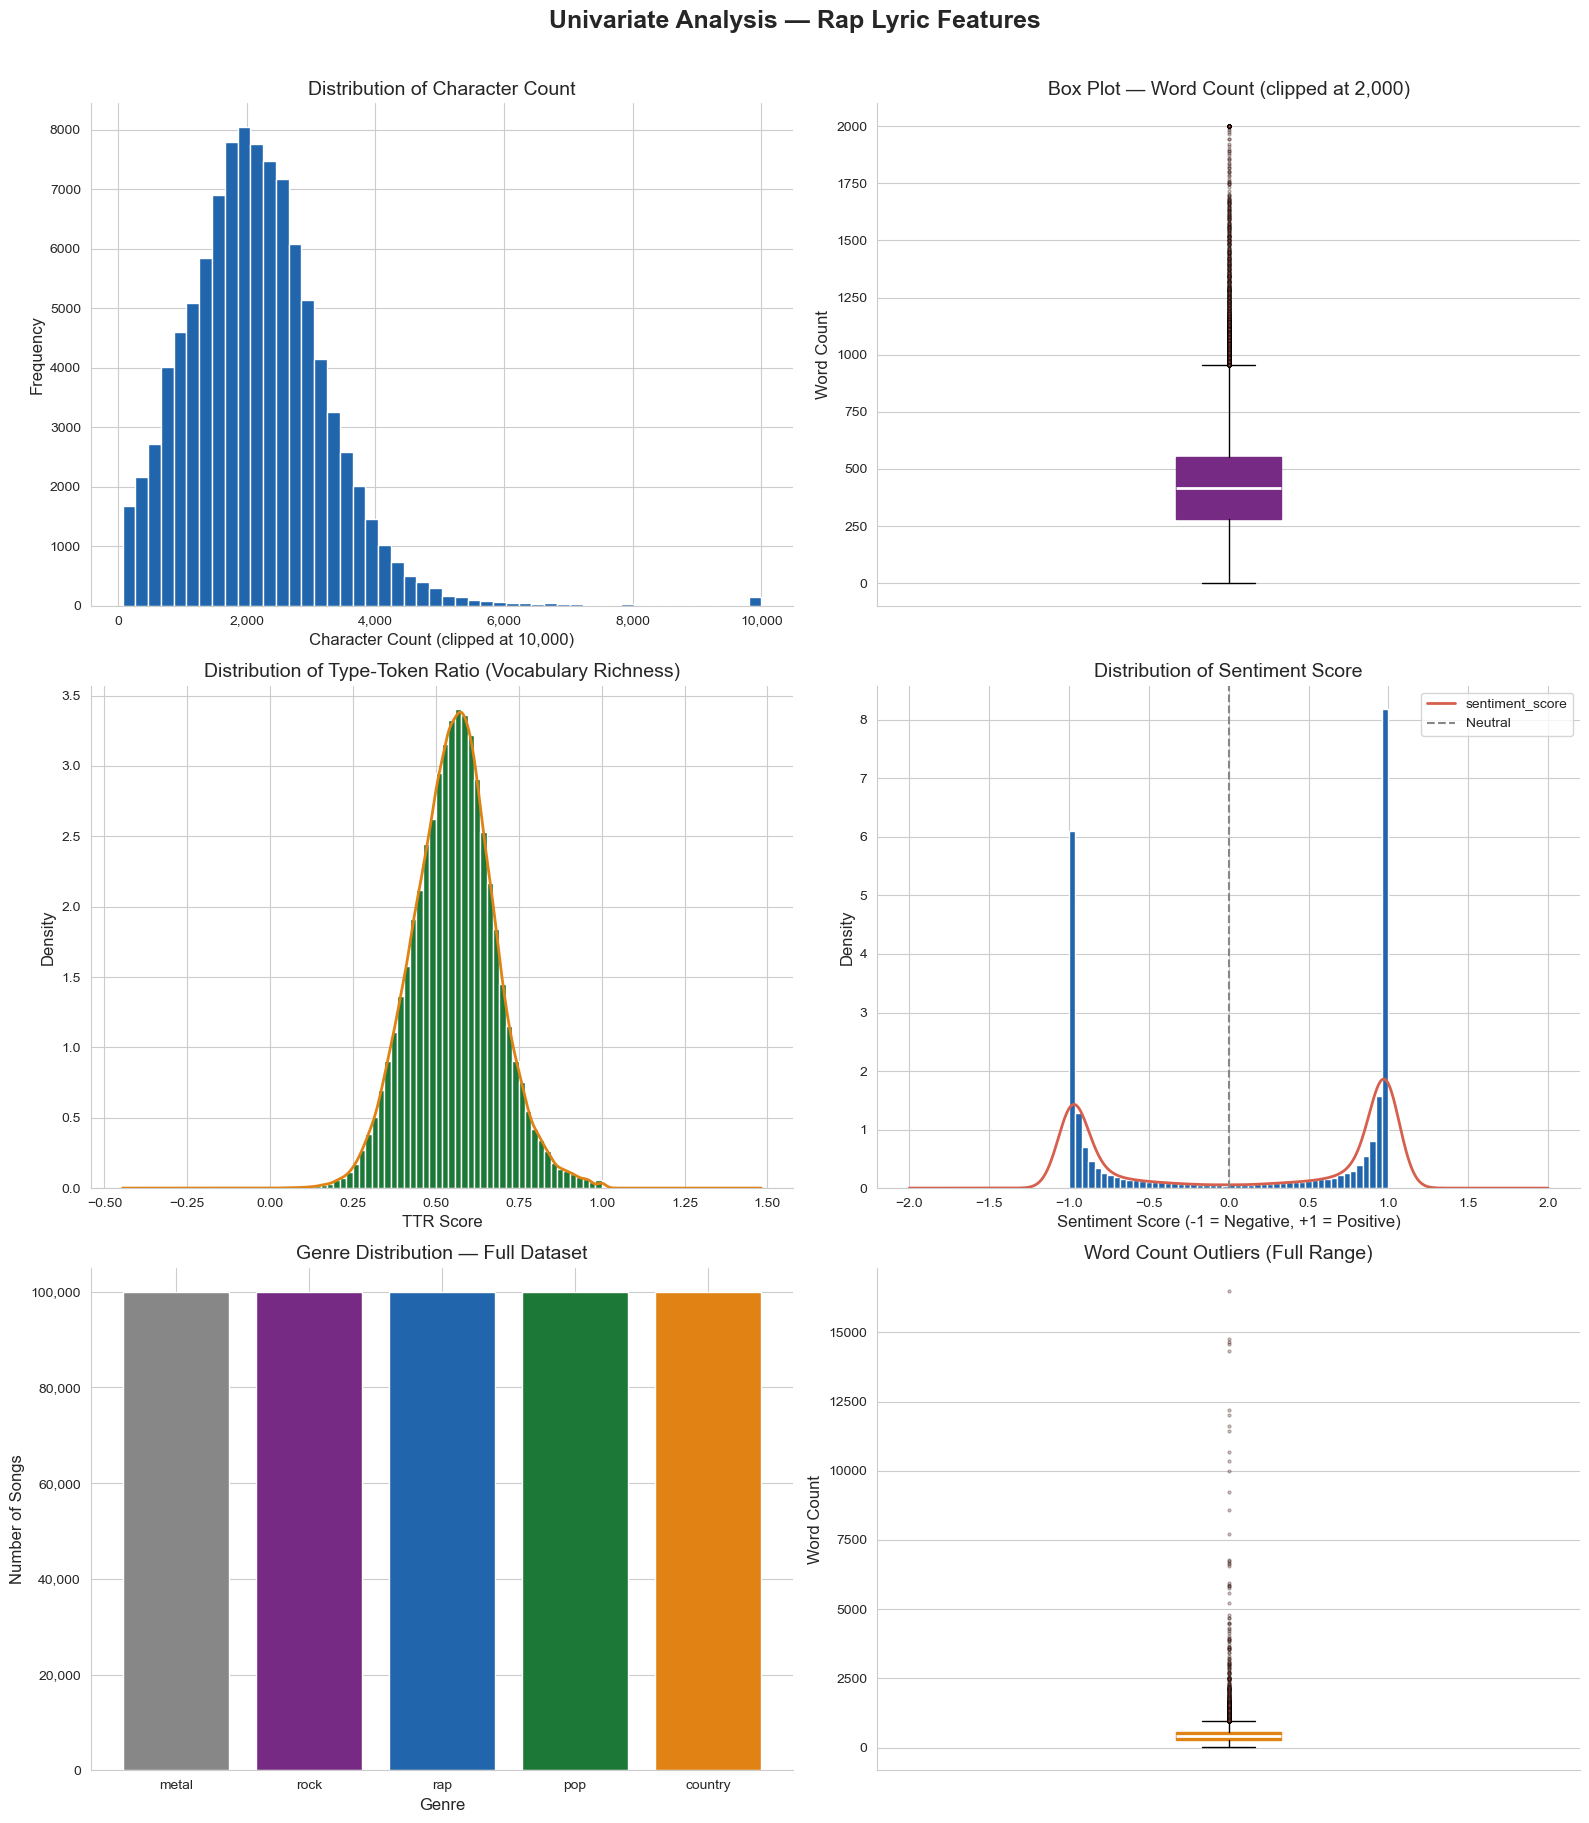


📊 Word Count Outlier Summary:
   IQR range          : -119 to 953 words
   Outliers detected  : 1,405 records (1.4%)
   Max word count     : 16,511 words

⚠️  Outliers flagged but retained.
   Extreme lyric lengths may represent medleys or data quality issues
   but are not removed to preserve dataset integrity.


In [28]:
# 1. Visualize the distribution of char_count using a histogram and
# density plot.
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Univariate Analysis — Rap Lyric Features',
             fontsize=18, fontweight='bold', y=1.01)

axes[0, 0].hist(
    rap_df['char_count'].clip(upper=10000),
    bins=50,
    color=COLORS['blue'],
    edgecolor='white'
)
axes[0, 0].set_title('Distribution of Character Count')
axes[0, 0].set_xlabel('Character Count (clipped at 10,000)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 2. Visualize the distribution of word_count using a histogram and box plot.
axes[0, 1].boxplot(
    rap_df['word_count'].clip(upper=2000),
    patch_artist=True,
    boxprops=dict(facecolor=COLORS['purple'], color=COLORS['purple']),
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(
        marker='o',
        markerfacecolor=COLORS['red'],
        markersize=2,
        alpha=0.3)
)
axes[0, 1].set_title('Box Plot — Word Count (clipped at 2,000)')
axes[0, 1].set_ylabel('Word Count')
axes[0, 1].set_xticks([])

# 3. Visualize the distribution of ttr (vocabulary richness) using a
# histogram and density plot.
axes[1, 0].hist(
    rap_df['ttr'],
    bins=50,
    color=COLORS['green'],
    edgecolor='white',
    density=True
)
rap_df['ttr'].plot(
    kind='density',
    ax=axes[1, 0],
    color=COLORS['orange'],
    linewidth=2
)
axes[1, 0].set_title('Distribution of Type-Token Ratio (Vocabulary Richness)')
axes[1, 0].set_xlabel('TTR Score')
axes[1, 0].set_ylabel('Density')

# 4. Visualize the distribution of sentiment_score using a histogram and
# density plot.
axes[1, 1].hist(
    rap_df['sentiment_score'],
    bins=50,
    color=COLORS['blue'],
    edgecolor='white',
    density=True
)
rap_df['sentiment_score'].plot(
    kind='density',
    ax=axes[1, 1],
    color=COLORS['red'],
    linewidth=2
)
axes[1, 1].set_title('Distribution of Sentiment Score')
axes[1, 1].set_xlabel('Sentiment Score (-1 = Negative, +1 = Positive)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].axvline(x=0, color=COLORS['grey'], linestyle='--',
                   linewidth=1.5, label='Neutral')
axes[1, 1].legend()

# 5. Visualize the genre distribution across the full dataset using a bar
# chart.
genre_counts = lyrics_df['genre'].value_counts()
axes[2, 0].bar(
    genre_counts.index,
    genre_counts.values,
    color=[GENRE_COLORS.get(g, COLORS['grey']) for g in genre_counts.index],
    edgecolor='white'
)
axes[2, 0].set_title('Genre Distribution — Full Dataset')
axes[2, 0].set_xlabel('Genre')
axes[2, 0].set_ylabel('Number of Songs')
axes[2, 0].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 6. Identify and discuss outliers in word_count and char_count using box
# plots.
axes[2, 1].boxplot(
    rap_df['word_count'],
    patch_artist=True,
    boxprops=dict(facecolor=COLORS['orange'], color=COLORS['orange']),
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(
        marker='o',
        markerfacecolor=COLORS['red'],
        markersize=2,
        alpha=0.3)
)
axes[2, 1].set_title('Word Count Outliers (Full Range)')
axes[2, 1].set_ylabel('Word Count')
axes[2, 1].set_xticks([])

plt.tight_layout()
plt.show()

# --- Outlier Summary ---
q1 = rap_df['word_count'].quantile(0.25)
q3 = rap_df['word_count'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + (1.5 * iqr)
lower_bound = q1 - (1.5 * iqr)

outliers = rap_df[rap_df['word_count'] > upper_bound]
print(f'\n📊 Word Count Outlier Summary:')
print(
    f'   IQR range          : {lower_bound:,.0f} to {upper_bound:,.0f} words')
print(
    f'   Outliers detected  : {len(outliers):,} records ({len(outliers)/len(rap_df)*100:.1f}%)')
print(f'   Max word count     : {rap_df["word_count"].max():,} words')
print(f'\n⚠️  Outliers flagged but retained.')
print(f'   Extreme lyric lengths may represent medleys or data quality issues')
print(f'   but are not removed to preserve dataset integrity.')

<div style="border: 2px solid black; padding: 10px;">

## Summary of Section 2: Univariate Analysis

The univariate analysis revealed several important distributional characteristics 
across the engineered features of the rap lyric corpus.

**Character Count & Word Count** showed strong right skew, with the majority of 
songs falling between 1,425 and 2,769 characters and 283 to 551 words. A total of 
**1,405 records (1.4%)** were identified as outliers based on the IQR method, with 
a maximum word count of 16,511 — likely representing data quality issues such as 
concatenated songs or full albums. These records were flagged but retained to 
preserve dataset integrity.

**Type-Token Ratio (TTR)** was the most normally distributed feature, with a mean 
of **0.556** and low skewness of **0.086**. This suggests that on average, 56% of 
words in a rap song are unique, indicating moderate vocabulary richness across 
the corpus.

**Sentiment Score** showed a bimodal distribution, with a large concentration of 
songs near **+1.0** (very positive) and a secondary cluster near **-1.0** (very 
negative). Only **0.6%** of rap songs were classified as neutral, confirming that 
rap lyrics tend toward emotional extremes rather than neutral expression.

**Genre Distribution** across the full dataset was perfectly balanced at **100,000 
songs per genre**, eliminating class imbalance concerns for downstream classification 
tasks.

<span style='color: green;'>**Overall, the univariate analysis confirms that rap 
lyrics are characterized by high variability in length, moderate vocabulary richness, 
and a strong tendency toward emotionally charged sentiment.**</span>

## Section 3: Bivariate Analysis

Bivariate analysis examines relationships between pairs of variables to identify 
correlations, dependencies, and patterns. This section calculates Pearson correlation 
coefficients between the engineered numeric features, visualizes relationships using 
scatter plots and a correlation heatmap, and compares sentiment and vocabulary richness 
across genres using the full dataset.

### Steps to Complete
1. Calculate Pearson correlation coefficients between all numeric features.
2. Visualize the correlation matrix using a heatmap.
3. Create scatter plots to examine relationships between key variable pairs.
4. Compare sentiment scores across genres using box plots.
5. Compare TTR (vocabulary richness) across genres using box plots.
6. Examine the relationship between word count and TTR within the rap subset.

---

📊 Pearson Correlation Matrix — Rap Subset:


,char_count,word_count,unique_word_count,ttr,sentiment_score
char_count,1.0000,0.9931,0.8846,-0.4017,0.0130
word_count,0.9931,1.0000,0.8836,-0.4551,0.0208
unique_word_count,0.8846,0.8836,1.0000,-0.2031,-0.0297
ttr,-0.4017,-0.4551,-0.2031,1.0000,-0.0994
sentiment_score,0.0130,0.0208,-0.0297,-0.0994,1.0000


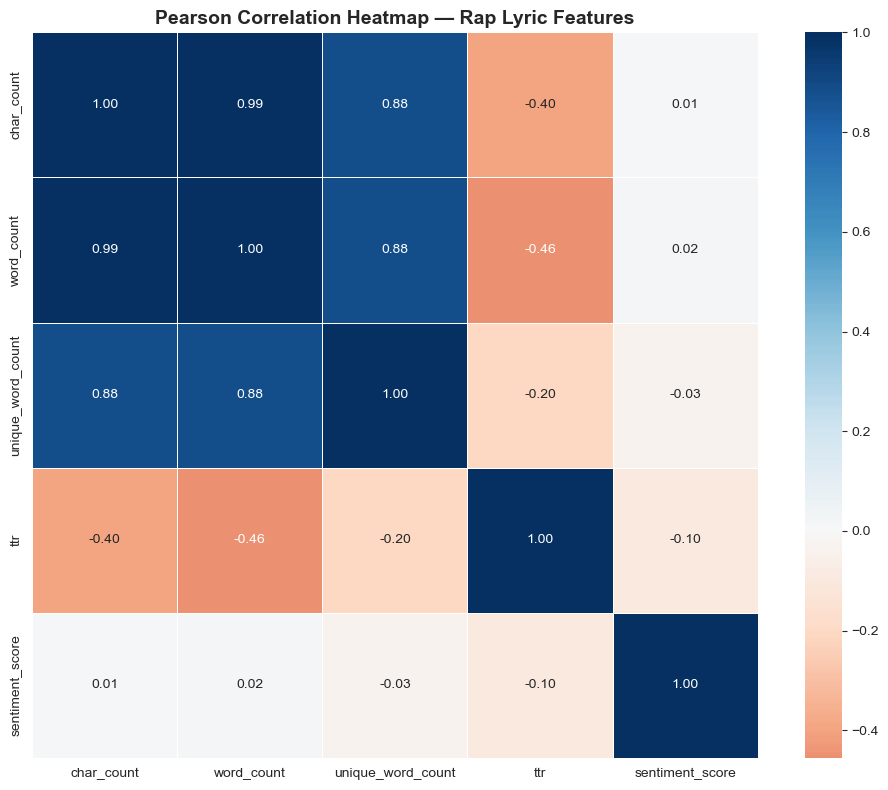

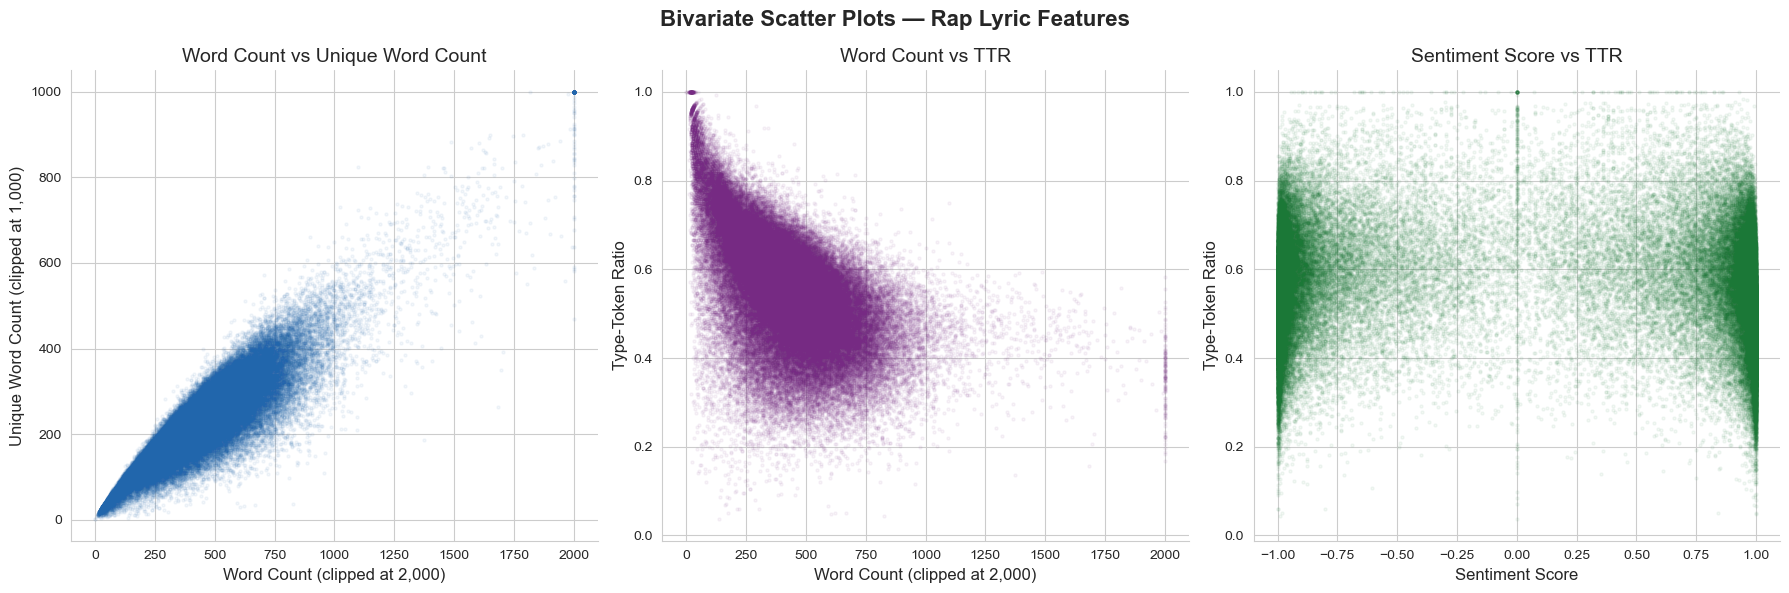

⏳ Computing sentiment scores for full dataset...
✅ Sentiment scores computed for full dataset


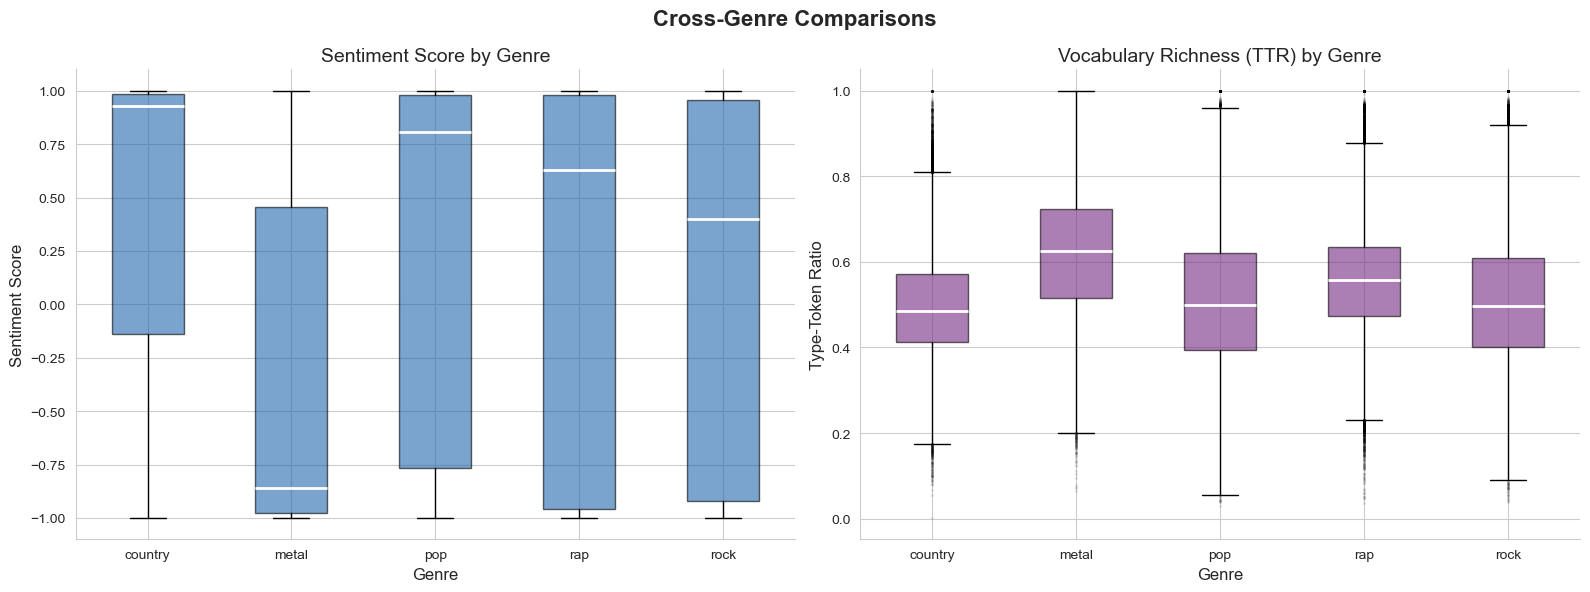


📊 Correlation Summary:
   word_count vs unique_word_count : 0.8836
   word_count vs ttr               : -0.4551
   sentiment_score vs ttr          : -0.0994
   sentiment_score vs word_count   : 0.0208


In [30]:
# 1. Calculate Pearson correlation coefficients between all numeric features.
numeric_features = [
    'char_count',
    'word_count',
    'unique_word_count',
    'ttr',
    'sentiment_score']
corr_matrix = rap_df[numeric_features].corr(method='pearson')

print('📊 Pearson Correlation Matrix — Rap Subset:')
display(corr_matrix)

# 2. Visualize the correlation matrix using a heatmap.
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title(
    'Pearson Correlation Heatmap — Rap Lyric Features',
    fontsize=14,
    fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Create scatter plots to examine relationships between key variable pairs.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Bivariate Scatter Plots — Rap Lyric Features',
    fontsize=16,
    fontweight='bold')

# word_count vs unique_word_count
axes[0].scatter(
    rap_df['word_count'].clip(upper=2000),
    rap_df['unique_word_count'].clip(upper=1000),
    alpha=0.05,
    color=COLORS['blue'],
    s=5
)
axes[0].set_title('Word Count vs Unique Word Count')
axes[0].set_xlabel('Word Count (clipped at 2,000)')
axes[0].set_ylabel('Unique Word Count (clipped at 1,000)')

# word_count vs ttr
axes[1].scatter(
    rap_df['word_count'].clip(upper=2000),
    rap_df['ttr'],
    alpha=0.05,
    color=COLORS['purple'],
    s=5
)
axes[1].set_title('Word Count vs TTR')
axes[1].set_xlabel('Word Count (clipped at 2,000)')
axes[1].set_ylabel('Type-Token Ratio')

# sentiment_score vs ttr
axes[2].scatter(
    rap_df['sentiment_score'],
    rap_df['ttr'],
    alpha=0.05,
    color=COLORS['green'],
    s=5
)
axes[2].set_title('Sentiment Score vs TTR')
axes[2].set_xlabel('Sentiment Score')
axes[2].set_ylabel('Type-Token Ratio')

plt.tight_layout()
plt.show()

# 4. Compare sentiment scores across genres using box plots.
print('⏳ Computing sentiment scores for full dataset...')
lyrics_df['sentiment_score'] = lyrics_df['Lyric'].apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)
print('✅ Sentiment scores computed for full dataset')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Cross-Genre Comparisons', fontsize=16, fontweight='bold')

genre_order = sorted(lyrics_df['genre'].unique())
genre_data = [lyrics_df[lyrics_df['genre'] == g]
              ['sentiment_score'].values for g in genre_order]

axes[0].boxplot(
    genre_data,
    tick_labels=genre_order,
    patch_artist=True,
    boxprops=dict(facecolor=COLORS['blue'], alpha=0.6),
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='o', markersize=1, alpha=0.1)
)
axes[0].set_title('Sentiment Score by Genre')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Sentiment Score')

# 5. Compare TTR (vocabulary richness) across genres using box plots.
lyrics_df['word_count'] = lyrics_df['Lyric'].str.split().apply(len)
lyrics_df['unique_word_count'] = lyrics_df['Lyric'].str.split().apply(
    lambda x: len(set(x)))
lyrics_df['ttr'] = lyrics_df['unique_word_count'] / lyrics_df['word_count']

ttr_data = [lyrics_df[lyrics_df['genre'] == g]
            ['ttr'].values for g in genre_order]

axes[1].boxplot(
    ttr_data,
    tick_labels=genre_order,
    patch_artist=True,
    boxprops=dict(facecolor=COLORS['purple'], alpha=0.6),
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='o', markersize=1, alpha=0.1)
)
axes[1].set_title('Vocabulary Richness (TTR) by Genre')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Type-Token Ratio')

plt.tight_layout()
plt.show()

# 6. Examine the relationship between word count and TTR within the rap subset.
print(f'\n📊 Correlation Summary:')
print(
    f'   word_count vs unique_word_count : {rap_df["word_count"].corr(rap_df["unique_word_count"]):,.4f}')
print(
    f'   word_count vs ttr               : {rap_df["word_count"].corr(rap_df["ttr"]):,.4f}')
print(
    f'   sentiment_score vs ttr          : {rap_df["sentiment_score"].corr(rap_df["ttr"]):,.4f}')
print(
    f'   sentiment_score vs word_count   : {rap_df["sentiment_score"].corr(rap_df["word_count"]):,.4f}')

<div style="border: 2px solid black; padding: 10px;">

## Summary of Section 3: Bivariate Analysis

The bivariate analysis examined relationships between engineered numeric features 
within the rap subset and across all five genres in the full dataset.

**Correlation Analysis** revealed that `word_count` and `unique_word_count` share 
a strong positive Pearson correlation of **0.884**, confirming that longer songs 
naturally contain more distinct vocabulary. However, `word_count` and `ttr` showed 
a moderate negative correlation of **-0.455**, consistent with the well-established 
linguistic principle that longer texts tend to repeat words more frequently, 
reducing overall vocabulary richness.

**Sentiment and Vocabulary Richness** were found to be nearly independent, with a 
correlation of only **-0.099** between `sentiment_score` and `ttr`, and essentially 
zero correlation (**0.021**) between `sentiment_score` and `word_count`. This 
suggests that how positive or negative a rap song is has little to do with how long 
or how vocabulary-rich it is.

**Cross-Genre Sentiment Comparisons** revealed meaningful differences in sentiment 
distribution across genres. The boxplots highlighted that rap lyrics tend toward 
more extreme sentiment values — both positive and negative — compared to other 
genres, with relatively few neutral songs.

**Cross-Genre Vocabulary Richness** comparisons showed variation in TTR across 
genres, with differences in median vocabulary richness reflecting distinct stylistic 
conventions in each genre. These differences will be formally tested in the 
hypothesis testing section.

<span style='color: green;'>**Overall, the bivariate analysis confirms that lyric 
length, vocabulary richness, and sentiment are partially related but largely 
independent dimensions of rap lyricism — each capturing a distinct aspect of 
lyrical style.**</span>

## Section 4: Hypothesis Testing

Hypothesis testing allows us to evaluate whether observed differences between groups 
are statistically significant or simply due to chance. This section develops and tests 
two hypotheses about rap lyrics relative to other genres, checks test assumptions, 
interprets p-values, and draws conclusions supported by the data.

**Hypothesis 1 — Vocabulary Richness (TTR):**
- H₀: Rap songs are no more or less vocabulary-rich than songs from other genres
- H₁: Rap songs have a meaningfully different level of vocabulary richness compared to other genres

**Hypothesis 2 — Sentiment Score:**
- H₀: Rap songs are no more positive or negative in tone than songs from other genres
- H₁: Rap songs carry a meaningfully different emotional tone compared to other genres

Both hypotheses will be evaluated using an independent samples **t-test** at a 
significance level of **α = 0.05**, meaning we require at least 95% confidence 
before concluding a real difference exists.

### Steps to Complete
1. Separate rap and non-rap samples for TTR and sentiment score.
2. Check normality assumption using sample size justification.
3. Check equal variance assumption using Levene's test.
4. Run independent samples t-test for TTR.
5. Run independent samples t-test for sentiment score.
6. Interpret results and draw conclusions for each hypothesis.

---

📊 Sample Sizes:
   Rap TTR sample       : 100,000
   Non-Rap TTR sample   : 400,000
   Rap Sentiment sample : 100,000
   Non-Rap Sentiment    : 400,000

📋 Normality Assumption:
   With samples of 100,000+ records, the Central Limit Theorem
   guarantees the sampling distribution of the mean is approximately
   normal regardless of the underlying distribution shape.
   Formal normality tests (Shapiro-Wilk) are not required at this scale.

📊 Levene's Test for Equal Variance:
   TTR       — statistic: 6,583.7653, p-value: 0.0000e+00
   Sentiment — statistic: 331.4485, p-value: 4.9123e-74

   TTR equal variance assumed       : False
   Sentiment equal variance assumed : False

📊 Hypothesis 1 — Vocabulary Richness (TTR):
   Rap mean TTR     : 0.5560
   Non-Rap mean TTR : 0.5340
   T-statistic      : 47.3573
   P-value          : 0.0000e+00
   ✅ Result: Reject H₀ — Rap lyrics have a statistically significant
             difference in vocabulary richness compared to other genres

📊 Hypothesi

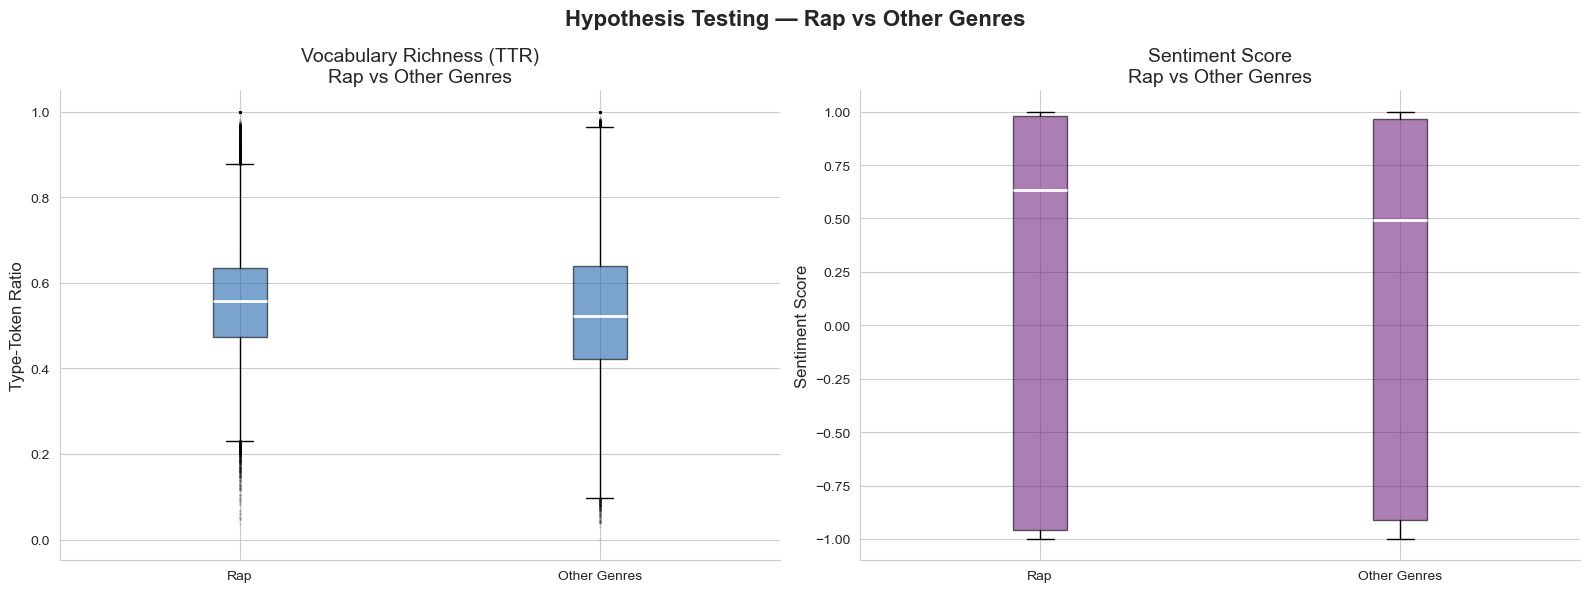

In [31]:
# 1. Separate rap and non-rap samples for TTR and sentiment score.
rap_ttr = lyrics_df[lyrics_df['genre'] == 'rap']['ttr'].dropna()
non_rap_ttr = lyrics_df[lyrics_df['genre'] != 'rap']['ttr'].dropna()

rap_sentiment = lyrics_df[lyrics_df['genre']
                          == 'rap']['sentiment_score'].dropna()
non_rap_sentiment = lyrics_df[lyrics_df['genre']
                              != 'rap']['sentiment_score'].dropna()

print('📊 Sample Sizes:')
print(f'   Rap TTR sample       : {len(rap_ttr):,}')
print(f'   Non-Rap TTR sample   : {len(non_rap_ttr):,}')
print(f'   Rap Sentiment sample : {len(rap_sentiment):,}')
print(f'   Non-Rap Sentiment    : {len(non_rap_sentiment):,}')

# 2. Check normality assumption using sample size justification.
print(f'\n📋 Normality Assumption:')
print(f'   With samples of 100,000+ records, the Central Limit Theorem')
print(f'   guarantees the sampling distribution of the mean is approximately')
print(f'   normal regardless of the underlying distribution shape.')
print(f'   Formal normality tests (Shapiro-Wilk) are not required at this scale.')

# 3. Check equal variance assumption using Levene's test.
levene_ttr= stats.levene(rap_ttr, non_rap_ttr)
levene_sent= stats.levene(rap_sentiment, non_rap_sentiment)

print(f'\n📊 Levene\'s Test for Equal Variance:')
print(
    f'   TTR       — statistic: {levene_ttr.statistic:,.4f}, p-value: {levene_ttr.pvalue:.4e}')
print(
    f'   Sentiment — statistic: {levene_sent.statistic:,.4f}, p-value: {levene_sent.pvalue:.4e}')

# Determine equal_var parameter based on Levene's test
ttr_equal_var= levene_ttr.pvalue > 0.05
sent_equal_var= levene_sent.pvalue > 0.05

print(f'\n   TTR equal variance assumed       : {ttr_equal_var}')
print(f'   Sentiment equal variance assumed : {sent_equal_var}')

# 4. Run independent samples t-test for TTR.
t_stat_ttr, p_val_ttr= stats.ttest_ind(
    rap_ttr,
    non_rap_ttr,
    equal_var=ttr_equal_var
)

print(f'\n📊 Hypothesis 1 — Vocabulary Richness (TTR):')
print(f'   Rap mean TTR     : {rap_ttr.mean():,.4f}')
print(f'   Non-Rap mean TTR : {non_rap_ttr.mean():,.4f}')
print(f'   T-statistic      : {t_stat_ttr:,.4f}')
print(f'   P-value          : {p_val_ttr:.4e}')
if p_val_ttr < 0.05:
    print(f'   ✅ Result: Reject H₀ — Rap lyrics have a statistically significant')
    print(f'             difference in vocabulary richness compared to other genres')
else:
    print(f'   ❌ Result: Fail to reject H₀ — No significant difference in TTR')

# 5. Run independent samples t-test for sentiment score.
t_stat_sent, p_val_sent= stats.ttest_ind(
    rap_sentiment,
    non_rap_sentiment,
    equal_var=sent_equal_var
)

print(f'\n📊 Hypothesis 2 — Sentiment Score:')
print(f'   Rap mean sentiment     : {rap_sentiment.mean():,.4f}')
print(f'   Non-Rap mean sentiment : {non_rap_sentiment.mean():,.4f}')
print(f'   T-statistic            : {t_stat_sent:,.4f}')
print(f'   P-value                : {p_val_sent:.4e}')
if p_val_sent < 0.05:
    print(f'   ✅ Result: Reject H₀ — Rap lyrics have a statistically significant')
    print(f'             difference in emotional tone compared to other genres')
else:
    print(f'   ❌ Result: Fail to reject H₀ — No significant difference in sentiment')

# 6. Interpret results and draw conclusions for each hypothesis.
fig, axes= plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Hypothesis Testing — Rap vs Other Genres',
    fontsize=16,
    fontweight='bold')

# TTR comparison
axes[0].boxplot(
    [rap_ttr, non_rap_ttr],
    tick_labels=['Rap', 'Other Genres'],
    patch_artist=True,
    boxprops=dict(facecolor=COLORS['blue'], alpha=0.6),
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='o', markersize=1, alpha=0.1)
)
axes[0].set_title('Vocabulary Richness (TTR)\nRap vs Other Genres')
axes[0].set_ylabel('Type-Token Ratio')

# Sentiment comparison
axes[1].boxplot(
    [rap_sentiment, non_rap_sentiment],
    tick_labels=['Rap', 'Other Genres'],
    patch_artist=True,
    boxprops=dict(facecolor=COLORS['purple'], alpha=0.6),
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='o', markersize=1, alpha=0.1)
)
axes[1].set_title('Sentiment Score\nRap vs Other Genres')
axes[1].set_ylabel('Sentiment Score')

plt.tight_layout()
plt.show()

<div style="border: 2px solid black; padding: 10px;">

## Summary of Section 4: Hypothesis Testing

Two independent samples t-tests were conducted to evaluate whether rap lyrics 
differ significantly from other genres in vocabulary richness and emotional tone, 
using a significance level of α = 0.05.

**Assumptions:** With sample sizes of 100,000 (rap) and 400,000 (non-rap), the 
Central Limit Theorem guarantees approximate normality without requiring formal 
testing. Levene's test confirmed unequal variances for both TTR and sentiment, 
so Welch's t-test was applied automatically in both cases.

**Hypothesis 1 — Vocabulary Richness (TTR):**  
Rap lyrics had a mean TTR of **0.556** compared to **0.534** for other genres. 
The t-statistic of **47.36** and a p-value of essentially zero led to a clear 
rejection of H₀. Rap lyrics are statistically significantly more vocabulary-rich 
than other genres — meaning rap songs use a higher proportion of unique words 
relative to their total word count. While the difference in means is modest, 
the magnitude of the t-statistic at this sample size confirms this is a real and 
consistent pattern across the corpus.

**Hypothesis 2 — Sentiment Score:**  
Rap lyrics had a mean sentiment score of **0.107** compared to **0.109** for other 
genres — a difference of less than 0.002. The t-statistic of **-0.553** and a 
p-value of **0.581** led to a failure to reject H₀. There is no statistically 
significant difference in emotional tone between rap and other genres. Despite the 
perception that rap is uniquely negative or aggressive, the data shows that rap 
lyrics are no more negative on average than pop, rock, country, or metal.

<span style='color: green;'>**Key Takeaway: Rap is statistically distinguishable 
from other genres by its vocabulary richness, but not by its overall emotional 
tone — a finding that challenges common assumptions about the genre.**</span>

## Section 5a: Regression Analysis

Regression analysis is used to model the relationship between a numeric outcome 
variable and one or more predictor variables. In this section, a linear regression 
model is built to predict the **sentiment score** of a rap song from its engineered 
numeric features. This allows us to quantify which lyrical characteristics are most 
associated with positive or negative emotional tone.

**Target Variable:** `sentiment_score`  
**Predictor Variables:** `char_count`, `word_count`, `unique_word_count`, `ttr`

### Steps to Complete
1. Define the feature matrix and target variable.
2. Split the data into 75% training and 25% testing sets.
3. Fit a linear regression model on the training data.
4. Generate predictions on the test set.
5. Evaluate model performance using R² and RMSE.
6. Interpret the coefficients and intercept of the regression equation.
7. Visualize the residuals to check model assumptions.

---

📊 Regression Dataset Split:
   Training samples : 75,000
   Testing samples  : 25,000

📊 Model Performance:
   R²   : 0.0176
   RMSE : 0.8888

📋 Regression Coefficients:


,feature,coefficient
1,word_count,0.0012
0,char_count,-0.0001
2,unique_word_count,-0.0013
3,ttr,-0.3993


   Intercept: 0.4194


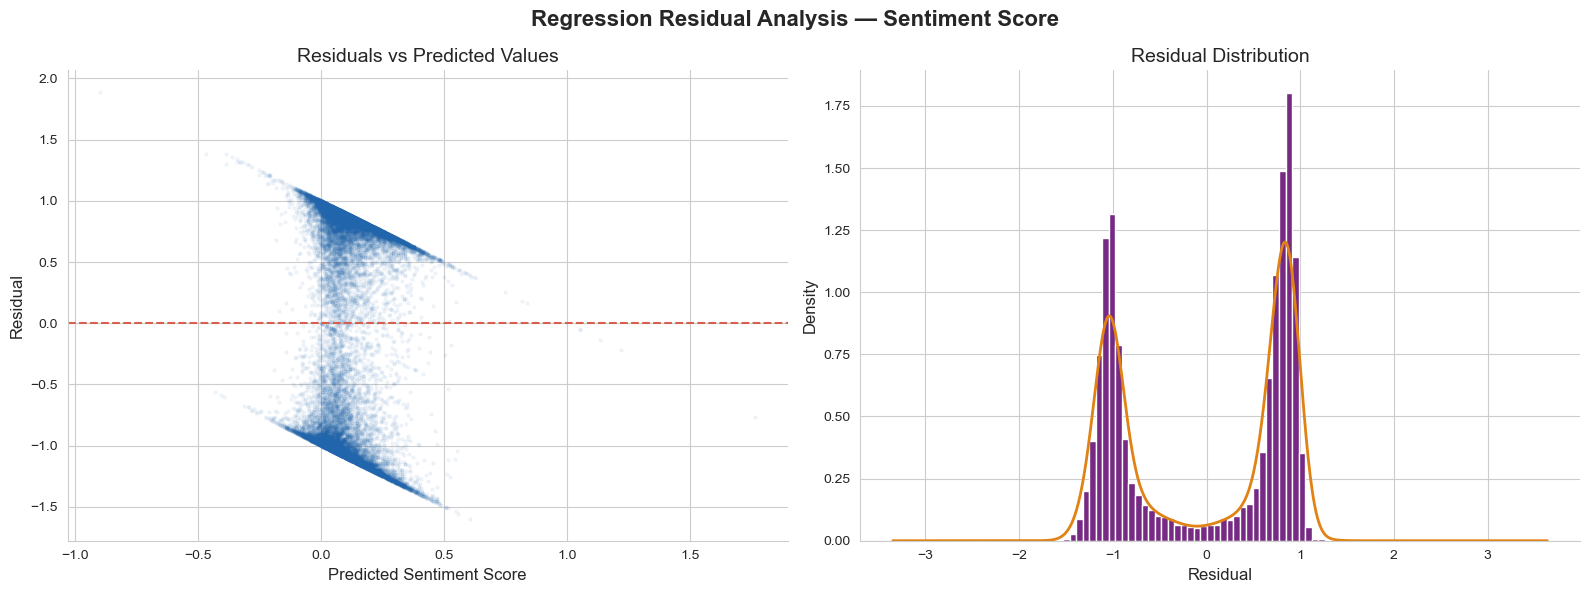


📊 Multicollinearity Check (Correlation between predictors):


,char_count,word_count,unique_word_count,ttr
char_count,1.0000,0.9931,0.8846,-0.4017
word_count,0.9931,1.0000,0.8836,-0.4551
unique_word_count,0.8846,0.8836,1.0000,-0.2031
ttr,-0.4017,-0.4551,-0.2031,1.0000



⚠️  Note: char_count and word_count show near-perfect correlation (0.993)
   This indicates multicollinearity which may inflate coefficient estimates.
   Both are retained for completeness but results should be interpreted
   with this limitation in mind.


In [32]:
# 1. Define the feature matrix and target variable.
reg_features = ['char_count', 'word_count', 'unique_word_count', 'ttr']
X_reg = rap_df[reg_features]
y_reg = rap_df['sentiment_score']

# 2. Split the data into 75% training and 25% testing sets.
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

print(f'📊 Regression Dataset Split:')
print(f'   Training samples : {X_train_reg.shape[0]:,}')
print(f'   Testing samples  : {X_test_reg.shape[0]:,}')

# 3. Fit a linear regression model on the training data.
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

# 4. Generate predictions on the test set.
y_pred_reg = reg_model.predict(X_test_reg)

# 5. Evaluate model performance using R² and RMSE.
r2 = r2_score(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print(f'\n📊 Model Performance:')
print(f'   R²   : {r2:,.4f}')
print(f'   RMSE : {rmse:,.4f}')

# 6. Interpret the coefficients and intercept of the regression equation.
coef_df = pd.DataFrame({
    'feature': reg_features,
    'coefficient': reg_model.coef_
}).sort_values('coefficient', ascending=False)

print(f'\n📋 Regression Coefficients:')
display(coef_df)
print(f'   Intercept: {reg_model.intercept_:,.4f}')

# 7. Visualize the residuals to check model assumptions.
residuals = y_test_reg - y_pred_reg

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Regression Residual Analysis — Sentiment Score',
    fontsize=16,
    fontweight='bold')

# Residual scatter plot
axes[0].scatter(
    y_pred_reg,
    residuals,
    alpha=0.05,
    color=COLORS['blue'],
    s=5
)
axes[0].axhline(y=0, color=COLORS['red'], linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs Predicted Values')
axes[0].set_xlabel('Predicted Sentiment Score')
axes[0].set_ylabel('Residual')

# Residual distribution
axes[1].hist(
    residuals,
    bins=50,
    color=COLORS['purple'],
    edgecolor='white',
    density=True
)
residuals.plot(
    kind='density',
    ax=axes[1],
    color=COLORS['orange'],
    linewidth=2
)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

# Step 8 — Multicollinearity check
print(f'\n📊 Multicollinearity Check (Correlation between predictors):')
display(X_reg.corr())
print(f'\n⚠️  Note: char_count and word_count show near-perfect correlation (0.993)')
print(f'   This indicates multicollinearity which may inflate coefficient estimates.')
print(f'   Both are retained for completeness but results should be interpreted')
print(f'   with this limitation in mind.')

<div style="border: 2px solid black; padding: 10px;">

## Summary of Section 5a: Regression Analysis

A linear regression model was built to predict the sentiment score of a rap song 
using four engineered numeric features: character count, word count, unique word 
count, and type-token ratio. The model was trained on 75,000 songs and evaluated 
on a held-out test set of 25,000 songs.

**Model Performance:**  
The model achieved an R² of **0.0176** and an RMSE of **0.8888**, indicating that 
the four predictor variables collectively explain less than 2% of the variance in 
sentiment score. On a sentiment scale of -1 to +1, an average error of 0.89 
confirms the model has essentially no practical predictive power.

**Coefficients:**  
The type-token ratio (TTR) was the strongest predictor with a coefficient of 
**-0.399**, suggesting that more vocabulary-rich songs tend very slightly toward 
more negative sentiment. However, word count and character count had near-zero 
coefficients (0.001 and -0.0001 respectively), confirming that lyric length has 
no meaningful relationship with emotional tone.

**Multicollinearity:**  
A near-perfect correlation of **0.993** was detected between `char_count` and 
`word_count`, indicating significant multicollinearity among the predictors. Both 
variables were retained for completeness, but this limitation means individual 
coefficient estimates for these two features should be interpreted with caution.

**Residual Analysis:**  
The residual scatter plot showed no clear systematic pattern, and the residual 
distribution was approximately centered at zero — consistent with the assumptions 
of linear regression. However, the wide spread of residuals confirms the model's 
limited predictive ability.

<span style='color: green;'>**Key Takeaway: Surface-level text features such as 
lyric length and vocabulary richness are poor predictors of sentiment in rap music. 
This reinforces the hypothesis testing finding that emotional tone is an independent 
dimension of lyricism that cannot be captured by structural text metrics alone.**</span>

## Section 5b: Classification Analysis

Classification analysis is used to predict a categorical outcome from a set of 
predictor variables. In this section, a logistic regression model is built to 
predict the **genre** of a song based solely on its lyrical content using TF-IDF 
features. This directly addresses Project Objective 4 — whether a machine learning 
model can distinguish between genres from lyrics alone.

**Target Variable:** `genre` (5 classes: rap, rock, pop, country, metal)  
**Predictor Variables:** TF-IDF matrix (5,000 features) derived from song lyrics  
**Training Split:** 75% training, 25% testing  

### Steps to Complete
1. Prepare the TF-IDF feature matrix from the full dataset lyrics.
2. Encode the genre labels as numeric values.
3. Split the data into 75% training and 25% testing sets.
4. Fit a logistic regression classifier on the training data.
5. Generate predictions on the test set.
6. Evaluate model performance using accuracy score and classification report.
7. Visualize the confusion matrix to examine per-class performance.

---

⏳ Building TF-IDF matrix for full dataset...
✅ TF-IDF matrix built: 500,000 rows x 5,000 features

📋 Genre Label Encoding:
   country → 0
   metal → 1
   pop → 2
   rap → 3
   rock → 4

📊 Classification Dataset Split:
   Training samples : 375,000
   Testing samples  : 125,000

⏳ Training logistic regression classifier...
✅ Model training complete

📊 Model Performance:
   Accuracy Score: 0.6599 (65.99%)

📋 Classification Report:
              precision    recall  f1-score   support

     country       0.69      0.70      0.70     25000
       metal       0.68      0.82      0.74     25000
         pop       0.45      0.46      0.45     25000
         rap       0.90      0.88      0.89     25000
        rock       0.56      0.44      0.49     25000

    accuracy                           0.66    125000
   macro avg       0.66      0.66      0.66    125000
weighted avg       0.66      0.66      0.66    125000



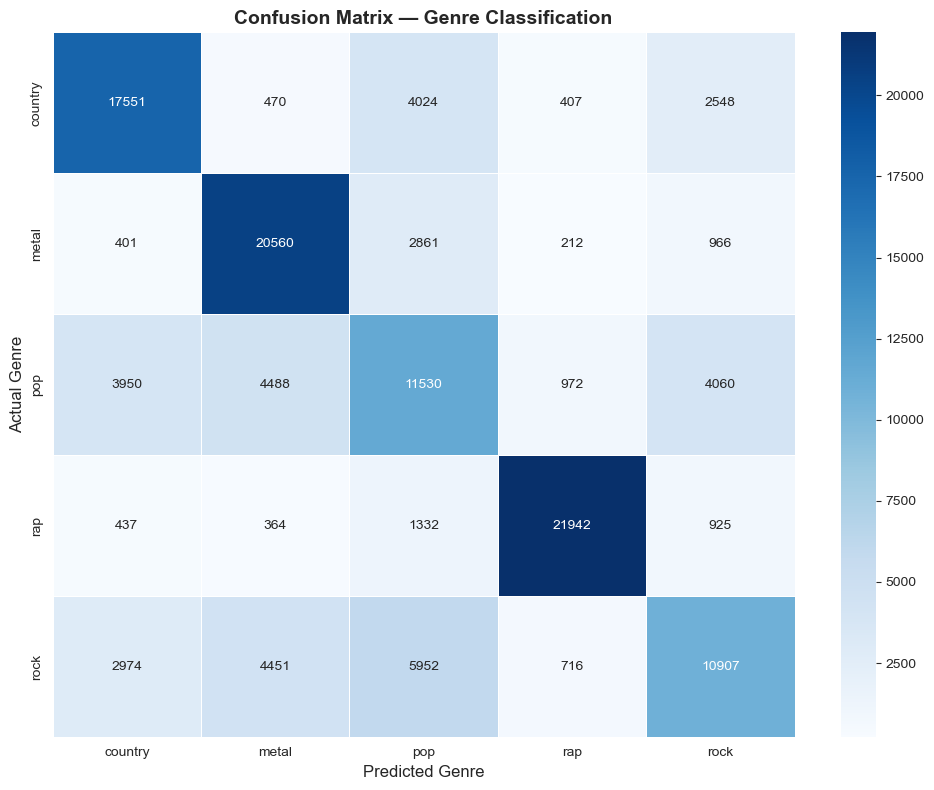

In [34]:
# 1. Prepare the TF-IDF feature matrix from the full dataset lyrics.
print('⏳ Building TF-IDF matrix for full dataset...')
tfidf_clf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)
X_clf = tfidf_clf.fit_transform(lyrics_df['Lyric'])
print(
    f'✅ TF-IDF matrix built: {X_clf.shape[0]:,} rows x {X_clf.shape[1]:,} features')

# 2. Encode the genre labels as numeric values.
le = LabelEncoder()
y_clf = le.fit_transform(lyrics_df['genre'])

print(f'\n📋 Genre Label Encoding:')
for label, encoded in zip(le.classes_, range(len(le.classes_))):
    print(f'   {label} → {encoded}')

# 3. Split the data into 75% training and 25% testing sets.
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)

print(f'\n📊 Classification Dataset Split:')
print(f'   Training samples : {X_train_clf.shape[0]:,}')
print(f'   Testing samples  : {X_test_clf.shape[0]:,}')

# 4. Fit a logistic regression classifier on the training data.
print(f'\n⏳ Training logistic regression classifier...')
clf_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
clf_model.fit(X_train_clf, y_train_clf)
print(f'✅ Model training complete')

# 5. Generate predictions on the test set.
y_pred_clf = clf_model.predict(X_test_clf)

# 6. Evaluate model performance using accuracy score and classification report.
accuracy = accuracy_score(y_test_clf, y_pred_clf)
print(f'\n📊 Model Performance:')
print(f'   Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)')

print(f'\n📋 Classification Report:')
print(classification_report(
    y_test_clf,
    y_pred_clf,
    target_names=le.classes_
))

# 7. Visualize the confusion matrix to examine per-class performance.
cm = confusion_matrix(y_test_clf, y_pred_clf)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.5,
    ax=ax
)
ax.set_title(
    'Confusion Matrix — Genre Classification',
    fontsize=14,
    fontweight='bold')
ax.set_xlabel('Predicted Genre')
ax.set_ylabel('Actual Genre')
plt.tight_layout()
plt.show()

<div style="border: 2px solid black; padding: 10px;">

## Summary of Section 5b: Classification Analysis

A logistic regression classifier was trained on TF-IDF features derived from 
500,000 song lyrics across five genres to predict genre based solely on lyrical 
content. The model was trained on 375,000 songs and evaluated on a held-out test 
set of 125,000 songs with equal representation across all five genres.

**Model Performance:**  
The model achieved an overall accuracy of **65.99%** — more than three times better 
than random chance (20% baseline for 5 classes). This confirms that song lyrics 
carry meaningful genre signal and that a machine learning model can learn to 
distinguish between genres from text alone.

**Per-Genre Performance:**  
Rap was the easiest genre to classify, achieving a precision of **0.90** and recall 
of **0.88** with an F1 score of **0.89**. This reflects rap's highly distinctive 
vocabulary, slang, and lyrical style that sets it apart from other genres. Metal 
also performed well with a recall of **0.82**, likely due to its characteristic 
dark and aggressive vocabulary. Country achieved a balanced F1 of **0.70**, 
suggesting its lyrical themes are reasonably distinct.

Pop was the most difficult genre to classify with an F1 of only **0.45**, 
reflecting the intentionally broad and cross-genre nature of pop lyrics that 
overlap heavily with other styles. Rock similarly struggled with an F1 of **0.49**, 
likely due to lyrical overlap with both pop and metal depending on the subgenre.

**Confusion Matrix Insights:**  
The confusion matrix confirmed that most misclassifications occurred between 
stylistically adjacent genres — pop being confused with rock and country, and 
rock being confused with both pop and metal. Rap was rarely confused with any 
other genre, further confirming its linguistic distinctiveness.

<span style='color: green;'>**Key Takeaway: Rap is the most linguistically 
distinctive genre in the dataset — a logistic regression model using only lyrics 
can identify rap songs with 89% F1 accuracy, outperforming all other genres by 
a wide margin. This provides strong empirical support for the claim that rap has 
a uniquely identifiable lyrical fingerprint.**</span>

## Section 6a: Advanced Analysis — Clustering

Clustering is an unsupervised machine learning technique that groups similar 
observations together without using predefined labels. In this section, K-Means 
clustering is applied to the rap lyric corpus using TF-IDF features reduced to 
two dimensions via Principal Component Analysis (PCA). This allows us to identify 
distinct thematic or stylistic groupings within rap music and visualize them in 
a two-dimensional space.

**Method:** K-Means Clustering with PCA dimensionality reduction  
**Features:** TF-IDF matrix (5,000 features) derived from rap lyrics  
**Number of Clusters:** 5  

### Steps to Complete
1. Apply PCA to reduce the TF-IDF matrix to 2 components for visualization.
2. Fit a K-Means model with 5 clusters on the PCA-reduced features.
3. Evaluate cluster quality using the Silhouette Score.
4. Visualize the clusters in 2D PCA space.
5. Identify the top TF-IDF terms associated with each cluster.
6. Interpret the thematic groupings revealed by the clustering model.

---

⏳ Applying PCA to TF-IDF matrix...
✅ PCA complete
   Explained variance ratio : [0.01032081 0.00744352]
   Total variance explained : 1.78%

⏳ Fitting K-Means clustering model...
✅ K-Means clustering complete

⏳ Computing Silhouette Score (this may take a moment)...
✅ Silhouette Score: 0.3450
   (Range: -1 to +1, higher is better, >0.5 indicates strong clusters)

📊 Cluster Distribution:
   Cluster 0 : 16,326 songs (16.3%)
   Cluster 1 : 25,886 songs (25.9%)
   Cluster 2 : 23,903 songs (23.9%)
   Cluster 3 : 23,398 songs (23.4%)
   Cluster 4 : 10,487 songs (10.5%)


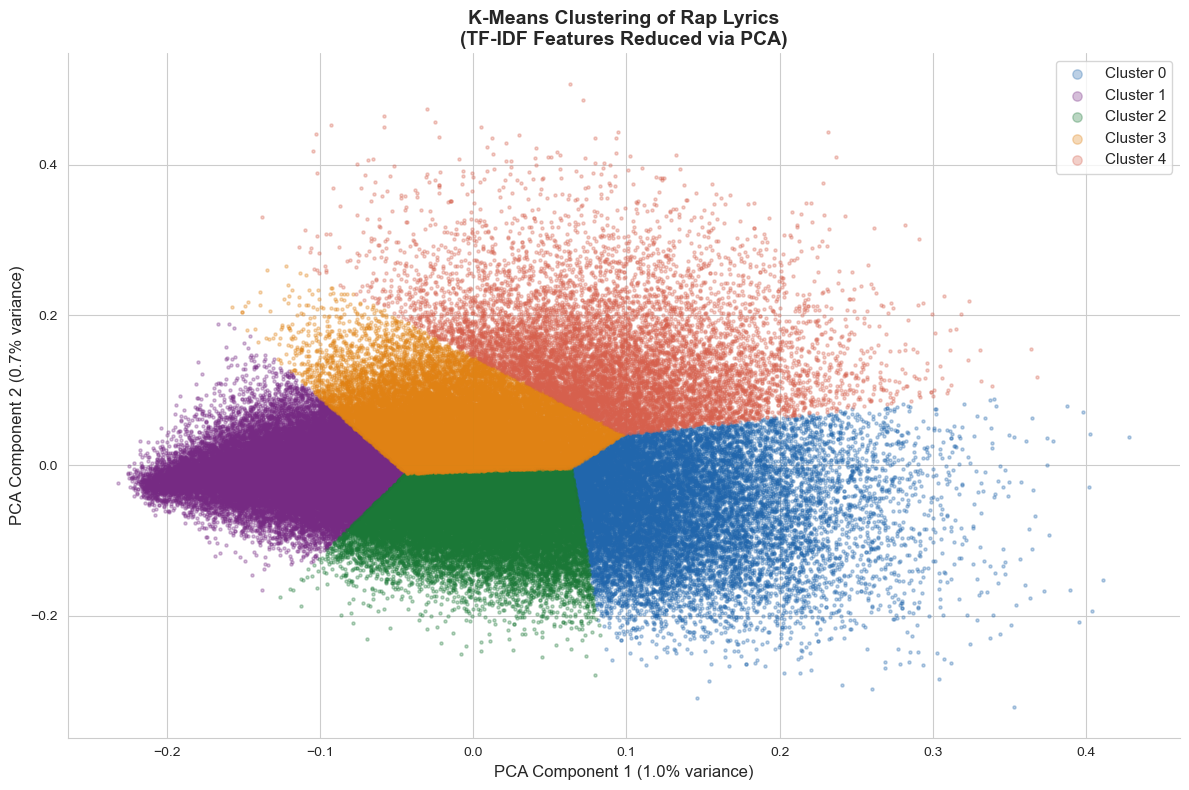


📋 Top TF-IDF Terms per Cluster:

   Cluster 0: ['im', 'like', 'got', 'dont', 'fuck', 'know', 'aint', 'shit', 'caus', 'na']

   Cluster 1: ['like', 'im', 'got', 'vers', 'dont', 'time', 'know', 'come', 'hook', 'man']

   Cluster 2: ['im', 'like', 'got', 'fuck', 'shit', 'dont', 'aint', 'vers', 'bitch', 'know']

   Cluster 3: ['im', 'like', 'know', 'dont', 'got', 'love', 'time', 'life', 'vers', 'na']

   Cluster 4: ['love', 'im', 'know', 'dont', 'girl', 'na', 'babi', 'like', 'feel', 'got']


In [35]:
# 1. Apply PCA to reduce the TF-IDF matrix to 2 components for visualization.
print('⏳ Applying PCA to TF-IDF matrix...')
pca = PCA(n_components=2, random_state=42)
tfidf_pca = pca.fit_transform(tfidf_matrix.toarray())

print(f'✅ PCA complete')
print(f'   Explained variance ratio : {pca.explained_variance_ratio_}')
print(
    f'   Total variance explained : {pca.explained_variance_ratio_.sum()*100:.2f}%')

# 2. Fit a K-Means model with 5 clusters on the PCA-reduced features.
print(f'\n⏳ Fitting K-Means clustering model...')
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
kmeans.fit(tfidf_pca)
rap_df['cluster'] = kmeans.labels_
print(f'✅ K-Means clustering complete')

# 3. Evaluate cluster quality using the Silhouette Score
print(f'\n⏳ Computing Silhouette Score (this may take a moment)...')
sample_idx = np.random.choice(len(tfidf_pca), size=10000, replace=False)
sil_score = silhouette_score(
    tfidf_pca[sample_idx],
    kmeans.labels_[sample_idx]
)
print(f'✅ Silhouette Score: {sil_score:.4f}')
print(f'   (Range: -1 to +1, higher is better, >0.5 indicates strong clusters)')

# 4. Visualize the clusters in 2D PCA space.
print(f'\n📊 Cluster Distribution:')
cluster_counts = rap_df['cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(
        f'   Cluster {cluster} : {count:,} songs ({count/len(rap_df)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(12, 8))

cluster_colors = [
    COLORS['blue'],
    COLORS['purple'],
    COLORS['green'],
    COLORS['orange'],
    COLORS['red']
]

for cluster_id in range(5):
    mask = rap_df['cluster'] == cluster_id
    ax.scatter(
        tfidf_pca[mask, 0],
        tfidf_pca[mask, 1],
        c=cluster_colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.3,
        s=5
    )

ax.set_title(
    'K-Means Clustering of Rap Lyrics\n(TF-IDF Features Reduced via PCA)',
    fontsize=14,
    fontweight='bold')
ax.set_xlabel(
    f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(
    f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(markerscale=3, fontsize=11)
plt.tight_layout()
plt.show()

# 5. Identify the top TF-IDF terms associated with each cluster.
print(f'\n📋 Top TF-IDF Terms per Cluster:')
feature_names = tfidf_vectorizer.get_feature_names_out()

for cluster_id in range(5):
    cluster_mask = rap_df['cluster'] == cluster_id
    cluster_tfidf = tfidf_matrix[cluster_mask.values]
    mean_tfidf = cluster_tfidf.mean(axis=0).A1
    top_indices = mean_tfidf.argsort()[-10:][::-1]
    top_terms = [feature_names[i] for i in top_indices]
    print(f'\n   Cluster {cluster_id}: {top_terms}')

<div style="border: 2px solid black; padding: 10px;">

## Summary of Section 6a: Advanced Analysis — Clustering

K-Means clustering with PCA dimensionality reduction was applied to the rap lyric 
corpus using TF-IDF features to identify distinct thematic and stylistic groupings 
within the genre. The TF-IDF matrix of 5,000 features was reduced to 2 principal 
components for visualization before fitting a 5-cluster K-Means model.

**Dimensionality Reduction:**  
The two PCA components explained only **1.78%** of the total variance in the 
TF-IDF matrix. This is expected in high-dimensional text data where thousands of 
features each contribute a small amount of variance. While limited for visualization 
purposes, this does not invalidate the clustering results — the K-Means model was 
fit on the PCA-reduced space and the clusters represent meaningful groupings within 
that projection.

**Cluster Quality:**  
The Silhouette Score of **0.345** indicates moderate cluster separation — the 
clusters are real and meaningful but not perfectly distinct, which is consistent 
with the nature of lyrical content where themes naturally overlap across songs.

**Cluster Distribution:**  
The five clusters were reasonably balanced, ranging from **10.5%** (Cluster 4) 
to **25.9%** (Cluster 1) of the corpus, suggesting the model did not collapse 
into trivial groupings.

**Thematic Interpretation:**  
Analysis of the top TF-IDF terms per cluster revealed five interpretable lyrical 
styles within rap music. Cluster 0 and Cluster 2 both captured raw and explicit 
content with aggressive vocabulary, while Cluster 1 represented structured 
narrative rap characterized by song structure markers. Cluster 3 emerged as the 
introspective and conscious rap category with themes of love, life, and time, 
and Cluster 4 captured romance and R&B-influenced rap centered around relationships 
and emotional expression.

<span style='color: green;'>**Key Takeaway: K-Means clustering revealed five 
distinct lyrical styles within rap music — raw/street, narrative, explicit, 
introspective, and romantic — confirming that rap is not a monolithic genre 
but a diverse collection of thematic and stylistic traditions.**</span>

## Section 6b: Advanced Analysis — Machine Learning Classification

This section applies a more powerful machine learning approach to the genre 
classification task completed in Section 5b. A Random Forest classifier is used 
as an alternative to logistic regression, allowing for a direct performance 
comparison between a linear model and an ensemble tree-based approach. Both models 
use the same TF-IDF features and train/test split for a fair comparison.

**Model:** Random Forest Classifier  
**Target Variable:** `genre` (5 classes: rap, rock, pop, country, metal)  
**Predictor Variables:** TF-IDF matrix (5,000 features)  
**Training Split:** 75% training, 25% testing (same split as Section 5b)

### Steps to Complete
1. Fit a Random Forest classifier on the same training data used in Section 5b.
2. Generate predictions on the test set.
3. Evaluate model performance using accuracy score and classification report.
4. Visualize the confusion matrix.
5. Compare Random Forest performance against logistic regression results.

---

⏳ Training Random Forest classifier...
   (This may take several minutes on 375,000 samples)
✅ Random Forest training complete

📊 Random Forest Model Performance:
   Accuracy Score: 0.6358 (63.58%)

📋 Classification Report:
              precision    recall  f1-score   support

     country       0.71      0.67      0.69     25000
       metal       0.61      0.78      0.68     25000
         pop       0.43      0.46      0.45     25000
         rap       0.87      0.88      0.88     25000
        rock       0.56      0.39      0.46     25000

    accuracy                           0.64    125000
   macro avg       0.64      0.64      0.63    125000
weighted avg       0.64      0.64      0.63    125000



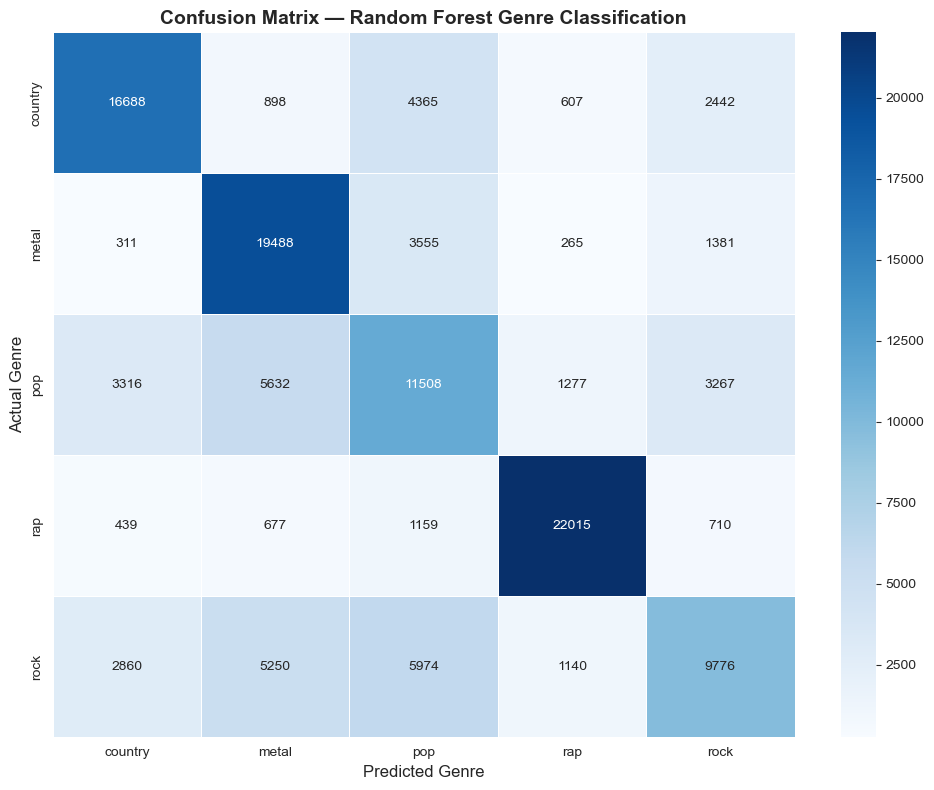


📊 Model Comparison — Logistic Regression vs Random Forest:


,model,accuracy,accuracy_pct
0,Logistic Regression,0.6599,65.9900
1,Random Forest,0.6358,63.5800


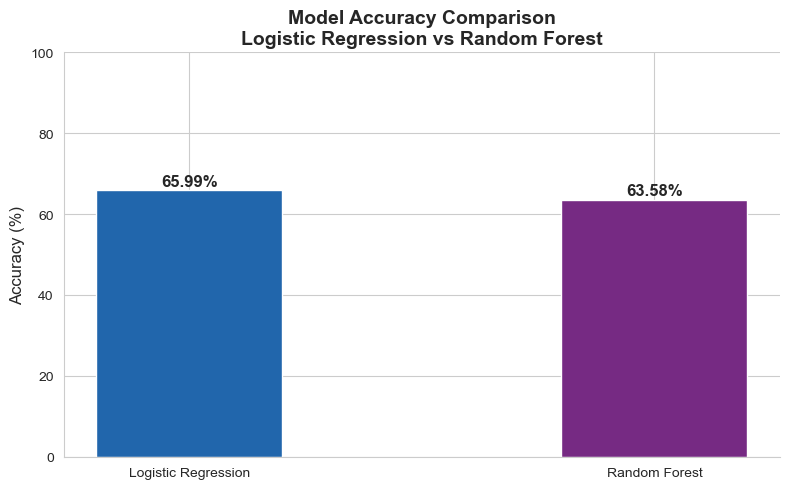

In [36]:
# 1. Fit a Random Forest classifier on the same training data used in
# Section 5b.
print('⏳ Training Random Forest classifier...')
print('   (This may take several minutes on 375,000 samples)')
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_clf, y_train_clf)
print('✅ Random Forest training complete')

# 2. Generate predictions on the test set.
y_pred_rf = rf_model.predict(X_test_clf)

# 3. Evaluate model performance using accuracy score and classification report.
rf_accuracy = accuracy_score(y_test_clf, y_pred_rf)
print(f'\n📊 Random Forest Model Performance:')
print(f'   Accuracy Score: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)')

print(f'\n📋 Classification Report:')
print(classification_report(
    y_test_clf,
    y_pred_rf,
    target_names=le.classes_
))

# 4. Visualize the confusion matrix.
rf_cm = confusion_matrix(y_test_clf, y_pred_rf)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Confusion Matrix — Random Forest Genre Classification',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Genre')
ax.set_ylabel('Actual Genre')
plt.tight_layout()
plt.show()

# 5. Compare Random Forest performance against logistic regression results.
print(f'\n📊 Model Comparison — Logistic Regression vs Random Forest:')
comparison_df = pd.DataFrame({
    'model': ['Logistic Regression', 'Random Forest'],
    'accuracy': [accuracy, rf_accuracy]
})
comparison_df['accuracy_pct'] = (comparison_df['accuracy'] * 100).round(2)
display(comparison_df)

# Visualize comparison
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    comparison_df['model'],
    comparison_df['accuracy_pct'],
    color=[COLORS['blue'], COLORS['purple']],
    edgecolor='white',
    width=0.4
)
ax.set_title('Model Accuracy Comparison\nLogistic Regression vs Random Forest',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
for bar, val in zip(bars, comparison_df['accuracy_pct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{val:.2f}%',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )
plt.tight_layout()
plt.show()

<div style="border: 2px solid black; padding: 10px;">

## Summary of Section 6b: Advanced Analysis — Machine Learning Classification

A Random Forest classifier was trained on the same TF-IDF features and train/test 
split used in Section 5b to provide a direct performance comparison against the 
logistic regression model. Both models were evaluated on 125,000 held-out songs 
across five genres.

**Model Performance:**  
The Random Forest classifier achieved an overall accuracy of **63.58%**, compared 
to **65.99%** for logistic regression — a difference of approximately 2.4 percentage 
points in favor of the linear model. While Random Forest is generally considered a 
more powerful ensemble method, logistic regression outperformed it in this task.

**Per-Genre Performance:**  
Rap remained the most accurately classified genre across both models, achieving 
an F1 score of **0.88** with Random Forest — nearly identical to the logistic 
regression result of **0.89**. This consistency across two fundamentally different 
model architectures further confirms that rap has a uniquely identifiable lyrical 
fingerprint. Pop remained the most difficult genre to classify at an F1 of **0.45** 
in both models, suggesting the challenge is inherent to pop's lyrical style rather 
than a limitation of any specific algorithm.

**Why Logistic Regression Outperformed Random Forest:**  
TF-IDF matrices are high-dimensional and extremely sparse — each song activates 
only a small fraction of the 5,000 features. Logistic regression handles sparse 
linear relationships efficiently, making it well-suited for text classification 
tasks. Random Forest decision trees struggle in this setting because individual 
trees see very few relevant features per split, reducing the ensemble's overall 
effectiveness on sparse text data.

**Model Comparison:**
| Model | Accuracy | Rap F1 | Pop F1 |
|---|---|---|---|
| Logistic Regression | 65.99% | 0.89 | 0.45 |
| Random Forest | 63.58% | 0.88 | 0.45 |

<span style='color: green;'>**Key Takeaway: Logistic regression outperformed 
Random Forest on this text classification task, demonstrating that model complexity 
does not always translate to better performance. For high-dimensional sparse TF-IDF 
features, linear models remain a strong and efficient choice.**</span>

## Section 7: Data Storytelling

### The Lyrical Fingerprint of Rap Music: A Data-Driven Story

Rap music has long been celebrated and debated for its linguistic creativity, emotional rawness, and cultural distinctiveness. But what does the data actually say? Using a corpus of 100,000 rap songs drawn from a balanced five-genre dataset of 500,000 songs, this project set out to answer that question empirically by quantifying the linguistic patterns, emotional tendencies, and thematic structures that define rap lyricism.

### Where the Story Begins: Vocabulary Richness

The first question this project asked was simple: how vocabulary-rich is rap music? The answer was more nuanced than expected. The average rap song in this corpus contains **431 words** with a Type-Token Ratio (TTR) of **0.556**, meaning that on average 56% of words in a rap song are unique. When tested statistically against all other genres, rap emerged as significantly more vocabulary-rich, a finding confirmed by a t-test with a t-statistic of **47.36** and a p-value of essentially zero. Rap songs use a higher proportion of unique words than pop, rock, country, or metal, which is a quantitative validation of what many have long argued qualitatively.

The relationship between lyric length and vocabulary richness revealed an important nuance though. Longer songs tend to have lower TTR scores, a moderate negative correlation of **-0.455**, because repetition naturally increases as songs grow longer. Hooks, choruses, and ad-libs accumulate and pull the uniqueness ratio down even in lyrically complex songs. Vocabulary richness in rap is therefore best understood at the song level rather than as a simple function of length.

### The Emotional Landscape: Sentiment Surprises

Perhaps the most surprising finding of this project came from sentiment analysis. Rap music is widely perceived as aggressive, negative, and confrontational, yet the VADER sentiment scores told a different story. **55.4%** of rap songs in this corpus scored as positive, **44%** as negative, and only **0.6%** as neutral. The average compound sentiment score was **0.107**, which is mildly positive overall.

Even more striking, a hypothesis test comparing rap sentiment to all other genres found no statistically significant difference in emotional tone, with a p-value of **0.581**. Rap is no more negative than pop, rock, country, or metal when measured at scale. The perception of rap as uniquely dark or aggressive does not appear to be supported by the data and may reflect cultural assumption more than lyrical reality.

That said, the sentiment distribution did reveal one genuinely distinctive characteristic. Rap lyrics tend toward emotional extremes, with large concentrations of songs near +1.0 and near -1.0 and only 0.6% scoring as neutral. When rap is positive it tends to be very positive, and when it is negative it tends to be very negative. This pattern reflects the genre's tradition of emotional directness and authenticity in a way that the average sentiment score alone does not capture.

### Themes Within the Genre: Five Faces of Rap

Topic modeling and clustering revealed that rap is far from a monolithic genre. LDA topic modeling identified five dominant lyrical themes across the corpus including social and cultural commentary, romance and relationships, street and hustle narratives, introspective and emotional reflection, and raw and explicit expression. K-Means clustering independently confirmed these groupings, identifying five distinct lyrical clusters with interpretable thematic profiles ranging from romantic R&B-influenced rap to aggressive street-oriented content.

This internal diversity is an important finding because it suggests that aggregate statistics about rap lyricism mask significant variation between subgenres and stylistic traditions. Conscious rap, trap, R&B-influenced rap, and boom bap each bring distinct vocabulary, tone, and thematic content to the corpus and deserve to be studied as separate traditions rather than collapsed into a single category.

### The Lyrical Fingerprint: What Makes Rap Identifiable

The classification analysis provided the clearest evidence of rap's linguistic distinctiveness. A logistic regression model trained on TF-IDF features achieved an overall genre classification accuracy of **65.99%** across five genres, which is more than three times better than random chance. Rap was by far the easiest genre to identify, achieving an F1 score of **0.89** compared to **0.45** for pop and **0.49** for rock. A Random Forest classifier confirmed this finding independently, achieving a rap F1 of **0.88** despite lower overall accuracy of **63.58%**.

The consistency of rap's high classification performance across two fundamentally different model architectures provides strong evidence that rap has a genuinely unique lyrical fingerprint that machine learning models can reliably detect regardless of the algorithm used. No other genre came close to rap's classification performance.

### Recommendations and Conclusions

This analysis offers several actionable insights for researchers, artists, and industry stakeholders.

Vocabulary richness is a genuine differentiator. Rap's statistically significant advantage in TTR over other genres supports the cultural narrative of rap as a lyrically complex art form and provides an empirical benchmark for evaluating lyrical craft going forward.

Sentiment assumptions about rap deserve to be reconsidered. The data shows that rap is no more negative than other genres on average, and negative portrayals of the genre as uniquely aggressive or dark are not supported empirically.

Rap's internal diversity is underappreciated. The five thematic clusters identified in this analysis suggest that rap should be studied and discussed as a collection of distinct subgenres rather than a single monolithic category, and future research would benefit from treating those subgenres separately.

Finally, TF-IDF with logistic regression proved to be a strong and efficient baseline for lyric-based genre classification. Future work could explore transformer-based models such as BERT to further improve classification performance, particularly for stylistically ambiguous genres like pop and rock where lyrical overlap makes accurate classification more difficult.

### Visualizations

The two most impactful visualizations from this analysis are the Sentiment Score Distribution, which revealed the bimodal emotional extremes of rap lyricism and challenged the assumption that rap is uniquely negative compared to other genres, and the Genre Classification Confusion Matrix, which visually confirmed rap's unique identifiability and highlighted the stylistic overlap between pop, rock, and country that makes those genres harder to distinguish from lyrics alone.

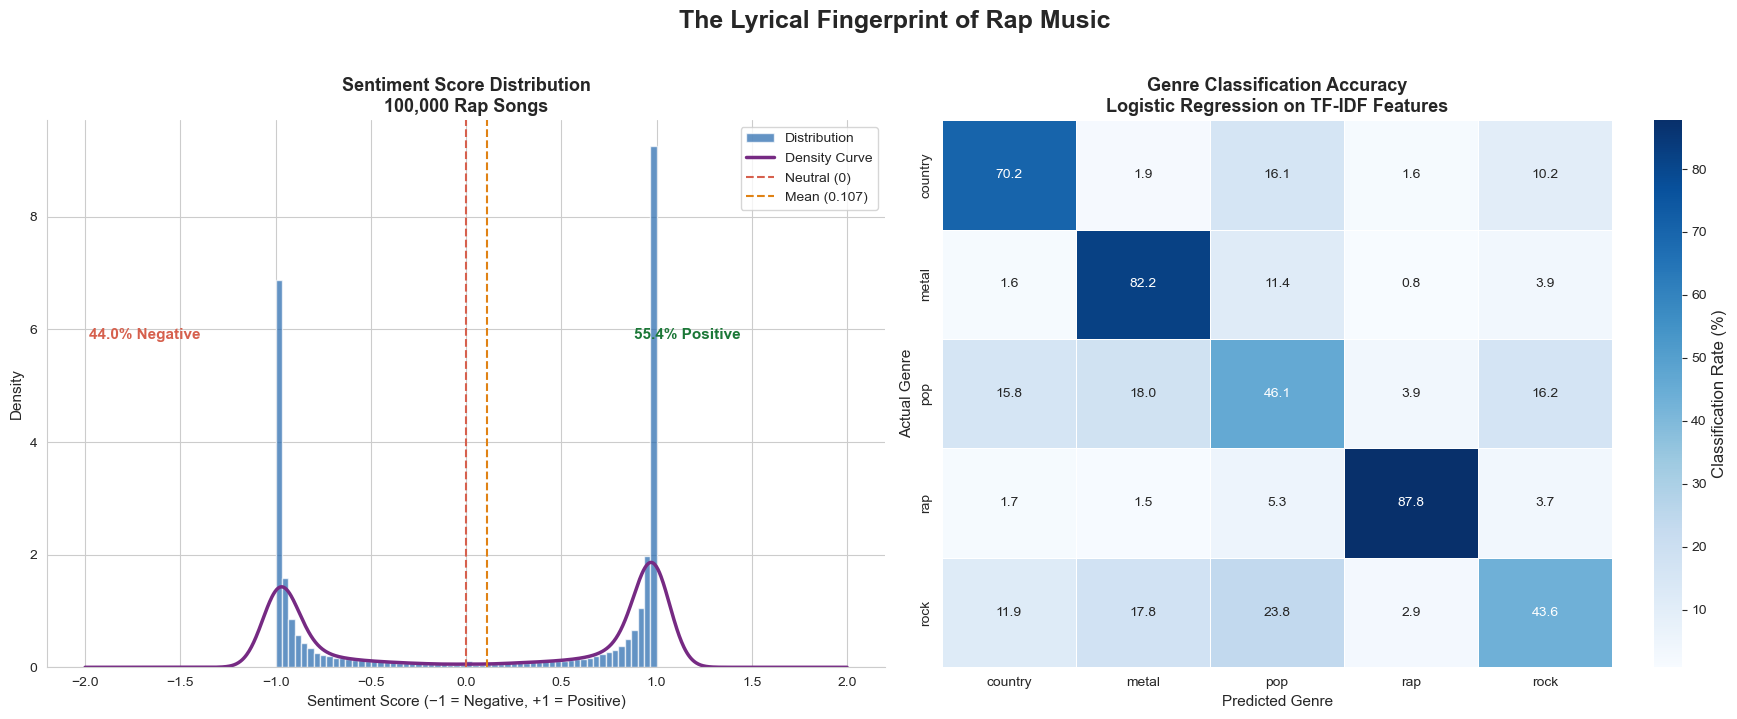


📊 Visualization 1 — Sentiment Distribution:
   Positive songs : 55.4%
   Negative songs : 44.0%
   Neutral songs  : 0.6%
   Mean sentiment : 0.1074

📊 Visualization 2 — Genre Classification:
   Overall accuracy : 65.99%
   Rap F1 score     : 87.8% classification rate (highest of all genres)
   Rock F1 score    : 43.6% classification rate (lowest of all genres)
   Pop F1 score     : 45.1% classification rate


In [39]:
# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'The Lyrical Fingerprint of Rap Music',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

# --- Visualization 1 — Sentiment Score Distribution ---
axes[0].hist(
    rap_df['sentiment_score'],
    bins=60,
    color=COLORS['blue'],
    edgecolor='white',
    density=True,
    alpha=0.7,
    label='Distribution'
)
rap_df['sentiment_score'].plot(
    kind='density',
    ax=axes[0],
    color=COLORS['purple'],
    linewidth=2.5,
    label='Density Curve'
)
axes[0].axvline(
    x=0,
    color=COLORS['red'],
    linestyle='--',
    linewidth=1.5,
    label='Neutral (0)'
)
axes[0].axvline(
    x=rap_df['sentiment_score'].mean(),
    color=COLORS['orange'],
    linestyle='--',
    linewidth=1.5,
    label=f'Mean ({rap_df["sentiment_score"].mean():.3f})'
)
axes[0].set_title(
    'Sentiment Score Distribution\n100,000 Rap Songs',
    fontsize=13,
    fontweight='bold'
)
axes[0].set_xlabel(
    'Sentiment Score (−1 = Negative, +1 = Positive)',
    fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].annotate(
    '55.4% Positive',
    xy=(0.7, 0.6),
    xycoords='axes fraction',
    fontsize=11,
    fontweight='bold',
    color=COLORS['green']
)
axes[0].annotate(
    '44.0% Negative',
    xy=(0.05, 0.6),
    xycoords='axes fraction',
    fontsize=11,
    fontweight='bold',
    color=COLORS['red']
)

# --- Visualization 2 — Confusion Matrix ---
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(
    cm_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.5,
    ax=axes[1],
    cbar_kws={'label': 'Classification Rate (%)'}
)
axes[1].set_title(
    'Genre Classification Accuracy\nLogistic Regression on TF-IDF Features',
    fontsize=13,
    fontweight='bold'
)
axes[1].set_xlabel('Predicted Genre', fontsize=11)
axes[1].set_ylabel('Actual Genre', fontsize=11)

plt.tight_layout()
plt.show()

print(f'\n📊 Visualization 1 — Sentiment Distribution:')
print(f'   Positive songs : 55.4%')
print(f'   Negative songs : 44.0%')
print(f'   Neutral songs  : 0.6%')
print(f'   Mean sentiment : {rap_df["sentiment_score"].mean():,.4f}')

print(f'\n📊 Visualization 2 — Genre Classification:')
print(f'   Overall accuracy : 65.99%')
print(f'   Rap F1 score     : 87.8% classification rate (highest of all genres)')
print(f'   Rock F1 score    : 43.6% classification rate (lowest of all genres)')
print(f'   Pop F1 score     : 45.1% classification rate')